<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Preop_AK_81125.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [178]:
import pandas as pd
import numpy as np

In [179]:
df = pd.read_excel('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months.xlsx')

In [180]:
df

,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth
0,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.50,-1.00,65.0
1,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.50,-2.00,80.0
2,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN
3,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.50,-0.50,150.0
4,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,45.00,46.25,165,6\36,6\18,-2.75,-3.00,75.0,6\12,-2,-2.50,110.0,6\12,-1.75,-2.25,90.0
170,41.00,42.50,85,CF @ 1M,6\18,NO CENTER,NaN,NaN,6\9,-2,-1.25,90.0,6\9,-1.00,-1.25,65.0
171,44.75,45.75,75,6\18,6\36,NO CENTER,NaN,NaN,6\18,-2.5,-4.25,10.0,NaN,NaN,NaN,NaN
172,44.75,45.25,170,6\36,6\18,NO CENTER,NaN,NaN,6\12,-1,3.25,150.0,NaN,NaN,NaN,NaN


In [181]:
df.shape

(174, 16)

In [182]:
df.columns

Index(['PreopR1', 'PreopR2', 'PreopA1', 'PreopVA', 'POD 1wkVA', 'Sph1wk',
       'Cyl1wk', 'Axis1wk', 'POD 6wkVA', 'Sph6wk ', 'Cyl6wk', 'Axis6wk',
       'POD 3mthVA', 'Sph3mth', 'Cyl3mth', 'Axis3mth'],
      dtype='object')

In [183]:
preop_akdata = df[['PreopR1', 'PreopR2', 'PreopA1']]


In [184]:
preop_akdata

,PreopR1,PreopR2,PreopA1
0,46.50,47.25,155
1,46.75,48.00,80
2,44.00,44.25,20
3,45.25,45.75,120
4,45.50,47.00,80
...,...,...,...
169,45.00,46.25,165
170,41.00,42.50,85
171,44.75,45.75,75
172,44.75,45.25,170


In [185]:
preop_akdata.shape

(174, 3)

In [186]:
preop_akdata.columns

Index(['PreopR1', 'PreopR2', 'PreopA1'], dtype='object')

In [187]:
preop_akdata.isnull().sum()

,0
PreopR1,0
PreopR2,0
PreopA1,0


In [188]:
preop_akdata.describe()

,PreopR1,PreopR2,PreopA1
count,174.000000,174.000000,174.000000
mean,44.432471,45.163793,100.201149
std,1.660740,1.963661,49.583115
min,40.000000,32.000000,5.000000
25%,43.250000,44.000000,70.000000
50%,44.500000,45.250000,87.500000
75%,45.500000,46.250000,148.750000
max,50.250000,50.750000,180.000000


In [189]:
preop_akdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PreopR1  174 non-null    float64
 1   PreopR2  174 non-null    float64
 2   PreopA1  174 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.2 KB


array([[<Axes: title={'center': 'PreopR1'}>,
        <Axes: title={'center': 'PreopR2'}>],
       [<Axes: title={'center': 'PreopA1'}>, <Axes: >]], dtype=object)

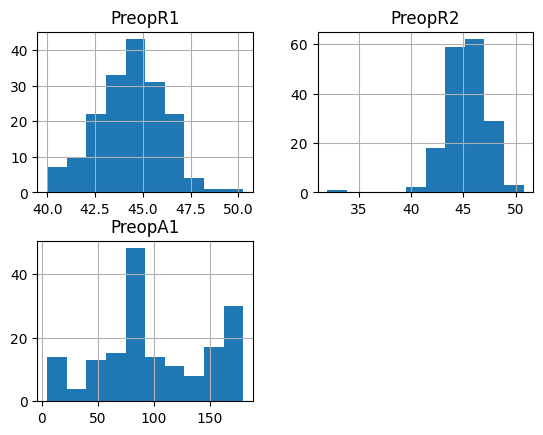

In [190]:
preop_akdata.hist()

<Axes: >

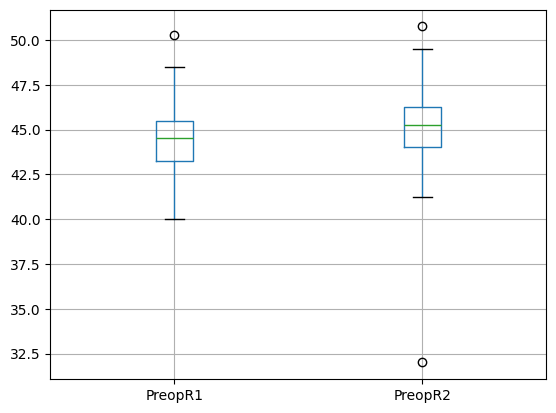

In [191]:
preop_akdata.boxplot(column=['PreopR1', 'PreopR2'])


In [192]:
# Remove outliers using IQR method
Q1 = preop_akdata[['PreopR1', 'PreopR2']].quantile(0.25)
Q3 = preop_akdata[['PreopR1', 'PreopR2']].quantile(0.75)
IQR = Q3 - Q1

preop_akdata_no_outliers = preop_akdata[~((preop_akdata[['PreopR1', 'PreopR2']] < (Q1 - 1.5 * IQR)) | (preop_akdata[['PreopR1', 'PreopR2']] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Shape of the DataFrame before removing outliers:", preop_akdata.shape)
print("Shape of the DataFrame after removing outliers:", preop_akdata_no_outliers.shape)

Shape of the DataFrame before removing outliers: (174, 3)
Shape of the DataFrame after removing outliers: (172, 3)


<Axes: >

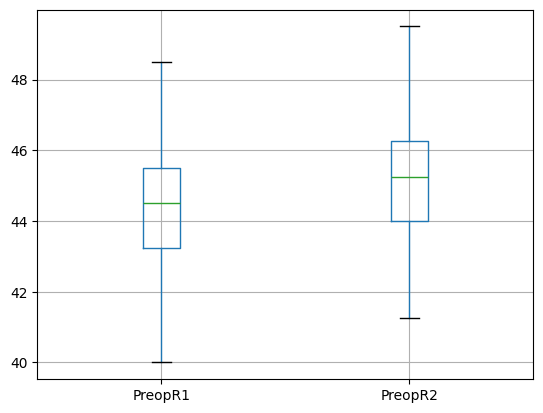

In [193]:
preop_akdata_no_outliers.boxplot(column=['PreopR1', 'PreopR2'])


array([[<Axes: title={'center': 'PreopR1'}>,
        <Axes: title={'center': 'PreopR2'}>],
       [<Axes: title={'center': 'PreopA1'}>, <Axes: >]], dtype=object)

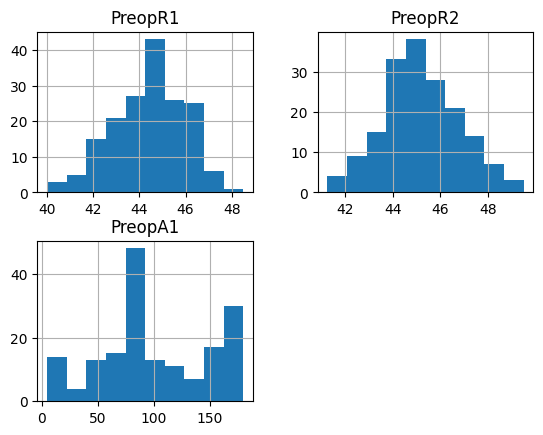

In [194]:
preop_akdata_no_outliers.hist()

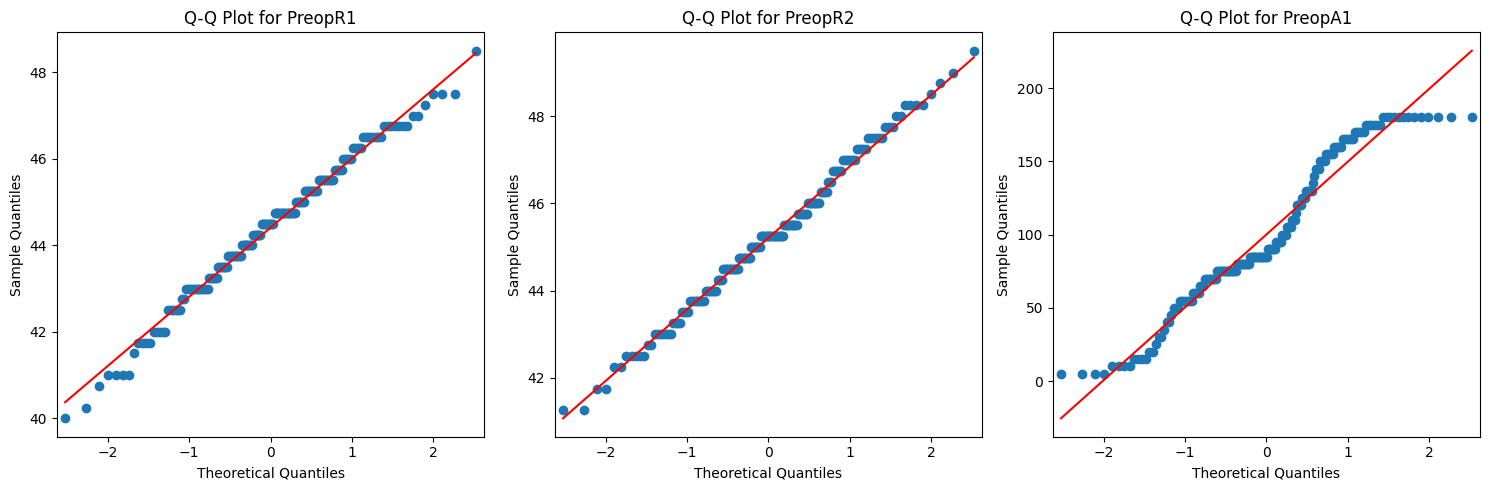

In [195]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sm.qqplot(preop_akdata_no_outliers['PreopR1'], line='s', ax=axes[0])
axes[0].set_title('Q-Q Plot for PreopR1')

sm.qqplot(preop_akdata_no_outliers['PreopR2'], line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot for PreopR2')

sm.qqplot(preop_akdata_no_outliers['PreopA1'], line='s', ax=axes[2])
axes[2].set_title('Q-Q Plot for PreopA1')

plt.tight_layout()
plt.show()

In [196]:
preop_akdata_no_outliers.describe()

,PreopR1,PreopR2,PreopA1
count,172.000000,172.000000,172.000000
mean,44.409884,45.207849,100.029070
std,1.603137,1.644158,49.819842
min,40.000000,41.250000,5.000000
25%,43.250000,44.000000,70.000000
50%,44.500000,45.250000,85.000000
75%,45.500000,46.250000,150.000000
max,48.500000,49.500000,180.000000


In [197]:
preop_akdata_no_outliers.corr()

,PreopR1,PreopR2,PreopA1
PreopR1,1.000000,0.940231,0.089270
PreopR2,0.940231,1.000000,0.077477
PreopA1,0.089270,0.077477,1.000000


In [198]:
from scipy import stats

ttest_result = stats.ttest_ind(preop_akdata_no_outliers['PreopR1'], preop_akdata_no_outliers['PreopR2'])

print(ttest_result)

TtestResult(statistic=np.float64(-4.557290330592242), pvalue=np.float64(7.222504863817106e-06), df=np.float64(342.0))


In [199]:
preop_akdata_no_outliers['R2_minus_R1'] = preop_akdata_no_outliers['PreopR2'] - preop_akdata_no_outliers['PreopR1']


/tmp/ipython-input-1197030202.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_akdata_no_outliers['R2_minus_R1'] = preop_akdata_no_outliers['PreopR2'] - preop_akdata_no_outliers['PreopR1']


In [200]:
preop_akdata_no_outliers

,PreopR1,PreopR2,PreopA1,R2_minus_R1
0,46.50,47.25,155,0.75
1,46.75,48.00,80,1.25
2,44.00,44.25,20,0.25
3,45.25,45.75,120,0.50
4,45.50,47.00,80,1.50
...,...,...,...,...
169,45.00,46.25,165,1.25
170,41.00,42.50,85,1.50
171,44.75,45.75,75,1.00
172,44.75,45.25,170,0.50


In [201]:
def classify_astigmatism(axis):
    if 60 <= axis <= 120:
        return 'With-the-Rule'
    elif (0 <= axis <= 30) or (150 <= axis <= 180):
        return 'Against-the-Rule'
    elif (31 <= axis <= 59) or (121 <= axis <= 149):
        return 'Oblique'
    else:
        return 'Unknown'

preop_akdata_no_outliers['Preop_Astigmatism_Type'] = preop_akdata_no_outliers['PreopA1'].apply(classify_astigmatism)


/tmp/ipython-input-2090817430.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_akdata_no_outliers['Preop_Astigmatism_Type'] = preop_akdata_no_outliers['PreopA1'].apply(classify_astigmatism)


In [202]:
preop_akdata_no_outliers

,PreopR1,PreopR2,PreopA1,R2_minus_R1,Preop_Astigmatism_Type
0,46.50,47.25,155,0.75,Against-the-Rule
1,46.75,48.00,80,1.25,With-the-Rule
2,44.00,44.25,20,0.25,Against-the-Rule
3,45.25,45.75,120,0.50,With-the-Rule
4,45.50,47.00,80,1.50,With-the-Rule
...,...,...,...,...,...
169,45.00,46.25,165,1.25,Against-the-Rule
170,41.00,42.50,85,1.50,With-the-Rule
171,44.75,45.75,75,1.00,With-the-Rule
172,44.75,45.25,170,0.50,Against-the-Rule


In [203]:
preop_akdata_no_outliers['Preop_Astigmatism_Type'].value_counts()


,count
Preop_Astigmatism_Type,
With-the-Rule,84
Against-the-Rule,61
Oblique,27


In [204]:
preop_akdata_no_outliers['Steep_Axis'] = (preop_akdata_no_outliers['PreopA1'] + 90) % 180

/tmp/ipython-input-1186122648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_akdata_no_outliers['Steep_Axis'] = (preop_akdata_no_outliers['PreopA1'] + 90) % 180


In [205]:
preop_akdata_no_outliers

,PreopR1,PreopR2,PreopA1,R2_minus_R1,Preop_Astigmatism_Type,Steep_Axis
0,46.50,47.25,155,0.75,Against-the-Rule,65
1,46.75,48.00,80,1.25,With-the-Rule,170
2,44.00,44.25,20,0.25,Against-the-Rule,110
3,45.25,45.75,120,0.50,With-the-Rule,30
4,45.50,47.00,80,1.50,With-the-Rule,170
...,...,...,...,...,...,...
169,45.00,46.25,165,1.25,Against-the-Rule,75
170,41.00,42.50,85,1.50,With-the-Rule,175
171,44.75,45.75,75,1.00,With-the-Rule,165
172,44.75,45.25,170,0.50,Against-the-Rule,80


In [206]:
preop_akdata_no_outliers['detaK'] = abs(preop_akdata_no_outliers['PreopR2'] - preop_akdata_no_outliers['PreopR1'])

/tmp/ipython-input-558751120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_akdata_no_outliers['detaK'] = abs(preop_akdata_no_outliers['PreopR2'] - preop_akdata_no_outliers['PreopR1'])


In [207]:
preop_akdata_no_outliers

,PreopR1,PreopR2,PreopA1,R2_minus_R1,Preop_Astigmatism_Type,Steep_Axis,detaK
0,46.50,47.25,155,0.75,Against-the-Rule,65,0.75
1,46.75,48.00,80,1.25,With-the-Rule,170,1.25
2,44.00,44.25,20,0.25,Against-the-Rule,110,0.25
3,45.25,45.75,120,0.50,With-the-Rule,30,0.50
4,45.50,47.00,80,1.50,With-the-Rule,170,1.50
...,...,...,...,...,...,...,...
169,45.00,46.25,165,1.25,Against-the-Rule,75,1.25
170,41.00,42.50,85,1.50,With-the-Rule,175,1.50
171,44.75,45.75,75,1.00,With-the-Rule,165,1.00
172,44.75,45.25,170,0.50,Against-the-Rule,80,0.50


In [208]:
def classify_astigmatism(axis):
    """Classify based on steep meridian axis."""
    if 60 <= axis <= 120:
        return "With-the-Rule"
    elif axis <= 30 or axis >= 150:
        return "Against-the-Rule"
    else:
        return "Oblique"

In [209]:
 preop_akdata_no_outliers['Astigmatism_Type'] =  preop_akdata_no_outliers['Steep_Axis'].apply (classify_astigmatism)

/tmp/ipython-input-1049887848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_akdata_no_outliers['Astigmatism_Type'] =  preop_akdata_no_outliers['Steep_Axis'].apply (classify_astigmatism)


In [210]:
preop_akdata_no_outliers

,PreopR1,PreopR2,PreopA1,R2_minus_R1,Preop_Astigmatism_Type,Steep_Axis,detaK,Astigmatism_Type
0,46.50,47.25,155,0.75,Against-the-Rule,65,0.75,With-the-Rule
1,46.75,48.00,80,1.25,With-the-Rule,170,1.25,Against-the-Rule
2,44.00,44.25,20,0.25,Against-the-Rule,110,0.25,With-the-Rule
3,45.25,45.75,120,0.50,With-the-Rule,30,0.50,Against-the-Rule
4,45.50,47.00,80,1.50,With-the-Rule,170,1.50,Against-the-Rule
...,...,...,...,...,...,...,...,...
169,45.00,46.25,165,1.25,Against-the-Rule,75,1.25,With-the-Rule
170,41.00,42.50,85,1.50,With-the-Rule,175,1.50,Against-the-Rule
171,44.75,45.75,75,1.00,With-the-Rule,165,1.00,Against-the-Rule
172,44.75,45.25,170,0.50,Against-the-Rule,80,0.50,With-the-Rule


In [211]:
print("Kurtosis:")
display(preop_akdata_no_outliers.select_dtypes(include=np.number).kurt())

print("\nSkewness:")
display(preop_akdata_no_outliers.select_dtypes(include=np.number).skew())

Kurtosis:


,0
PreopR1,-0.118221
PreopR2,-0.249358
PreopA1,-0.894480
R2_minus_R1,2.074089
Steep_Axis,-1.241594
detaK,2.153972



Skewness:


,0
PreopR1,-0.255752
PreopR2,0.067869
PreopA1,0.082534
R2_minus_R1,1.189028
Steep_Axis,-0.224020
detaK,1.286953


In [212]:
display(preop_akdata_no_outliers[['detaK', 'Steep_Axis']].describe())

,detaK,Steep_Axis
count,172.000000,172.000000
mean,0.803779,101.075581
std,0.554435,57.324664
min,0.000000,0.000000
25%,0.500000,60.000000
50%,0.750000,95.000000
75%,1.000000,160.000000
max,3.000000,175.000000


In [213]:
preop_akdata_no_outliers['Astigmatism_Type'].value_counts()

,count
Astigmatism_Type,
Against-the-Rule,84
With-the-Rule,61
Oblique,27


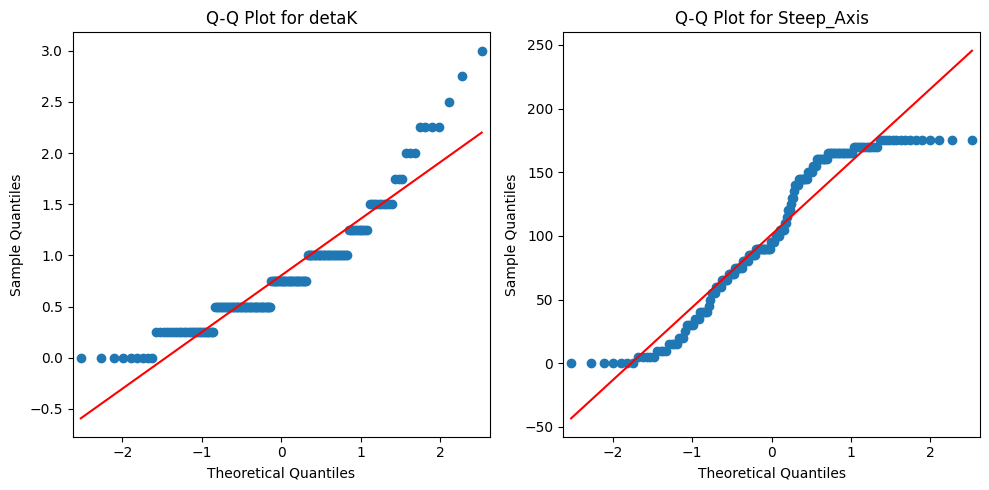

In [214]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sm.qqplot(preop_akdata_no_outliers['detaK'], line='s', ax=axes[0])
axes[0].set_title('Q-Q Plot for detaK')

sm.qqplot(preop_akdata_no_outliers['Steep_Axis'], line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot for Steep_Axis')

plt.tight_layout()
plt.show()

In [215]:
%pip install scikit-posthocs

In [216]:
from scikit_posthocs import posthoc_dunn

# Perform Dunn's post-hoc test
dunn_results = posthoc_dunn(preop_akdata_no_outliers, val_col='detaK', group_col='Astigmatism_Type', p_adjust='bonferroni')

print("Dunn's Post-Hoc Test Results:")
display(dunn_results)

Dunn's Post-Hoc Test Results:


,Against-the-Rule,Oblique,With-the-Rule
Against-the-Rule,1.000000,0.087076,0.012391
Oblique,0.087076,1.000000,1.000000
With-the-Rule,0.012391,1.000000,1.000000


In [217]:
from scipy.stats import kruskal

# Separate the detaK values into groups based on Astigmatism_Type
groups = [preop_akdata_no_outliers['detaK'][preop_akdata_no_outliers['Astigmatism_Type'] == category] for category in preop_akdata_no_outliers['Astigmatism_Type'].unique()]

# Perform the Kruskal-Wallis H test
kruskal_statistic, kruskal_pvalue = kruskal(*groups)

print(f"Kruskal-Wallis H test statistic: {kruskal_statistic}")
print(f"Kruskal-Wallis H test p-value: {kruskal_pvalue}")

Kruskal-Wallis H test statistic: 10.010241626852679
Kruskal-Wallis H test p-value: 0.00670353142270522


In [218]:
from scipy.stats import chisquare

# Get the observed frequencies of each astigmatism type
observed_frequencies = preop_akdata_no_outliers['Astigmatism_Type'].value_counts()

# For a goodness-of-fit test, you need expected frequencies.
# A common assumption is that all categories have equal expected frequencies.
# If you have a different expected distribution, please provide it.
total_count = observed_frequencies.sum()
number_of_categories = len(observed_frequencies)
expected_frequency_per_category = total_count / number_of_categories
expected_frequencies = [expected_frequency_per_category] * number_of_categories

# Perform the chi-squared goodness-of-fit test
chi2_statistic, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

print(f"Observed Frequencies:\n{observed_frequencies}")
print(f"\nExpected Frequencies: {expected_frequencies}")
print(f"\nChi-squared statistic: {chi2_statistic}")
print(f"P-value: {p_value}")

Observed Frequencies:
Astigmatism_Type
Against-the-Rule    84
With-the-Rule       61
Oblique             27
Name: count, dtype: int64

Expected Frequencies: [np.float64(57.333333333333336), np.float64(57.333333333333336), np.float64(57.333333333333336)]

Chi-squared statistic: 28.686046511627904
P-value: 5.900708303485922e-07


In [219]:
astigmatism_counts = preop_akdata_no_outliers['Astigmatism_Type'].value_counts()
print("Counts for Astigmatism Types:")
print(astigmatism_counts[['With-the-Rule', 'Against-the-Rule']])

Counts for Astigmatism Types:
Astigmatism_Type
With-the-Rule       61
Against-the-Rule    84
Name: count, dtype: int64


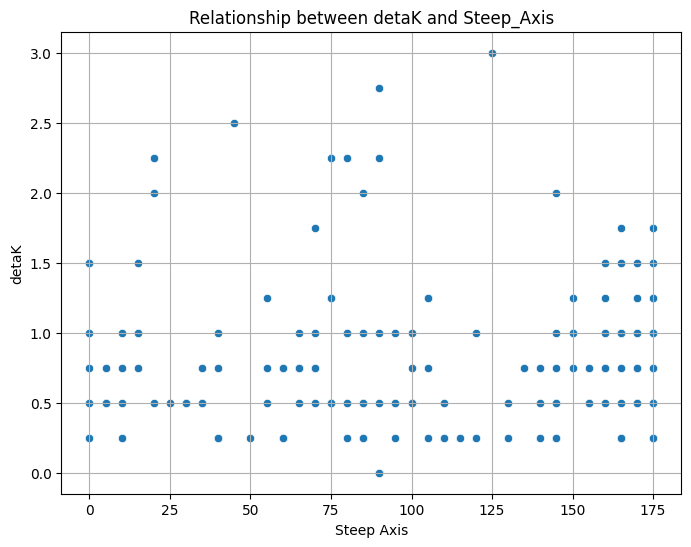

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=preop_akdata_no_outliers, x='Steep_Axis', y='detaK')
plt.title('Relationship between detaK and Steep_Axis')
plt.xlabel('Steep Axis')
plt.ylabel('detaK')
plt.grid(True)
plt.show()

In [221]:
from scipy.stats import mannwhitneyu

group1 = preop_akdata_no_outliers[preop_akdata_no_outliers['Astigmatism_Type'] == 'Oblique']['detaK']
group2 = preop_akdata_no_outliers[preop_akdata_no_outliers['Astigmatism_Type'] == 'Against-the-Rule']['detaK']

mannwhitneyu_result = mannwhitneyu(group1, group2)

print(f"Mann-Whitney U test statistic: {mannwhitneyu_result.statistic}")
print(f"Mann-Whitney U test p-value: {mannwhitneyu_result.pvalue}")

Mann-Whitney U test statistic: 802.5
Mann-Whitney U test p-value: 0.020511575892573207


In [222]:
from scipy.stats import spearmanr

spearman_corr, spearman_pvalue = spearmanr(preop_akdata_no_outliers['detaK'], preop_akdata_no_outliers['Steep_Axis'])

print(f"Spearman's rank correlation coefficient: {spearman_corr}")
print(f"Spearman's rank correlation p-value: {spearman_pvalue}")

Spearman's rank correlation coefficient: 0.11102568563826538
Spearman's rank correlation p-value: 0.14707043711458456


In [223]:
from scipy import stats

shapiro_detaK = stats.shapiro(preop_akdata_no_outliers['detaK'])
shapiro_steep_axis = stats.shapiro(preop_akdata_no_outliers['Steep_Axis'])

print("Shapiro-Wilk test for detaK:", shapiro_detaK)
print("Shapiro-Wilk test for Steep_Axis:", shapiro_steep_axis)

Shapiro-Wilk test for detaK: ShapiroResult(statistic=np.float64(0.8927780786302091), pvalue=np.float64(8.136539731214758e-10))
Shapiro-Wilk test for Steep_Axis: ShapiroResult(statistic=np.float64(0.9129386020304753), pvalue=np.float64(1.3828894191313304e-08))


In [224]:
import numpy as np
import pandas as pd

def calc_astig_vector(row):
    R1 = row['PreopR1']
    R2 = row['PreopR2']
    A1 = row['Steep_Axis']

    # Step 1: Astigmatism magnitude (difference between steep and flat)
    AstigMag = abs(R2 - R1)

    # Step 2: Convert axis (degrees) to radians (double-angle)
    theta_rad = np.deg2rad(2 * A1)

    # Step 3: Vector components
    X = AstigMag * np.cos(theta_rad)
    Y = AstigMag * np.sin(theta_rad)

    return pd.Series({'Preop_AstigMag': AstigMag, 'Preop_X': X, 'Preop_Y': Y})

# Apply to each row of your dataframe
preop_akdata_no_outliers[['Preop_AstigMag', 'Preop_X', 'Preop_Y']] = preop_akdata_no_outliers.apply(calc_astig_vector, axis=1)


/tmp/ipython-input-3774164449.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_akdata_no_outliers[['Preop_AstigMag', 'Preop_X', 'Preop_Y']] = preop_akdata_no_outliers.apply(calc_astig_vector, axis=1)
/tmp/ipython-input-3774164449.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_akdata_no_outliers[['Preop_AstigMag', 'Preop_X', 'Preop_Y']] = preop_akdata_no_outliers.apply(calc_astig_vector, axis=1)
/tmp/ipython-input-3774164449.py:22: SettingWithCopyWarning: 
A value is trying to be set on

In [225]:
preop_akdata_no_outliers

,PreopR1,PreopR2,PreopA1,R2_minus_R1,Preop_Astigmatism_Type,Steep_Axis,detaK,Astigmatism_Type,Preop_AstigMag,Preop_X,Preop_Y
0,46.50,47.25,155,0.75,Against-the-Rule,65,0.75,With-the-Rule,0.75,-0.482091,0.574533
1,46.75,48.00,80,1.25,With-the-Rule,170,1.25,Against-the-Rule,1.25,1.174616,-0.427525
2,44.00,44.25,20,0.25,Against-the-Rule,110,0.25,With-the-Rule,0.25,-0.191511,-0.160697
3,45.25,45.75,120,0.50,With-the-Rule,30,0.50,Against-the-Rule,0.50,0.250000,0.433013
4,45.50,47.00,80,1.50,With-the-Rule,170,1.50,Against-the-Rule,1.50,1.409539,-0.513030
...,...,...,...,...,...,...,...,...,...,...,...
169,45.00,46.25,165,1.25,Against-the-Rule,75,1.25,With-the-Rule,1.25,-1.082532,0.625000
170,41.00,42.50,85,1.50,With-the-Rule,175,1.50,Against-the-Rule,1.50,1.477212,-0.260472
171,44.75,45.75,75,1.00,With-the-Rule,165,1.00,Against-the-Rule,1.00,0.866025,-0.500000
172,44.75,45.25,170,0.50,Against-the-Rule,80,0.50,With-the-Rule,0.50,-0.469846,0.171010


In [226]:
import numpy as np

# Calculate resultant vector magnitude and axis
preop_akdata_no_outliers['Preop_Resultant_Mag'] = np.sqrt(preop_akdata_no_outliers['Preop_X']**2 + preop_akdata_no_outliers['Preop_Y']**2)

# Axis from vector components (divide angle by 2 to convert from double-angle space)
preop_akdata_no_outliers['Preop_Resultant_Axis'] = 0.5 * np.degrees(np.arctan2(preop_akdata_no_outliers['Preop_Y'], preop_akdata_no_outliers['Preop_X']))

# Normalize axis to 0–180 range
preop_akdata_no_outliers['Preop_Resultant_Axis'] = preop_akdata_no_outliers['Preop_Resultant_Axis'] % 180

/tmp/ipython-input-334217661.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_akdata_no_outliers['Preop_Resultant_Mag'] = np.sqrt(preop_akdata_no_outliers['Preop_X']**2 + preop_akdata_no_outliers['Preop_Y']**2)
/tmp/ipython-input-334217661.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preop_akdata_no_outliers['Preop_Resultant_Axis'] = 0.5 * np.degrees(np.arctan2(preop_akdata_no_outliers['Preop_Y'], preop_akdata_no_outliers['Preop_X']))
/tmp/ipython-input-334217661.py:10: SettingWithCopyWarnin

In [227]:
preop_akdata_no_outliers

,PreopR1,PreopR2,PreopA1,R2_minus_R1,Preop_Astigmatism_Type,Steep_Axis,detaK,Astigmatism_Type,Preop_AstigMag,Preop_X,Preop_Y,Preop_Resultant_Mag,Preop_Resultant_Axis
0,46.50,47.25,155,0.75,Against-the-Rule,65,0.75,With-the-Rule,0.75,-0.482091,0.574533,0.75,65.0
1,46.75,48.00,80,1.25,With-the-Rule,170,1.25,Against-the-Rule,1.25,1.174616,-0.427525,1.25,170.0
2,44.00,44.25,20,0.25,Against-the-Rule,110,0.25,With-the-Rule,0.25,-0.191511,-0.160697,0.25,110.0
3,45.25,45.75,120,0.50,With-the-Rule,30,0.50,Against-the-Rule,0.50,0.250000,0.433013,0.50,30.0
4,45.50,47.00,80,1.50,With-the-Rule,170,1.50,Against-the-Rule,1.50,1.409539,-0.513030,1.50,170.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,45.00,46.25,165,1.25,Against-the-Rule,75,1.25,With-the-Rule,1.25,-1.082532,0.625000,1.25,75.0
170,41.00,42.50,85,1.50,With-the-Rule,175,1.50,Against-the-Rule,1.50,1.477212,-0.260472,1.50,175.0
171,44.75,45.75,75,1.00,With-the-Rule,165,1.00,Against-the-Rule,1.00,0.866025,-0.500000,1.00,165.0
172,44.75,45.25,170,0.50,Against-the-Rule,80,0.50,With-the-Rule,0.50,-0.469846,0.171010,0.50,80.0


In [228]:
print("Descriptive Statistics:")
display(preop_akdata_no_outliers[['Preop_Resultant_Mag', 'Preop_Resultant_Axis']].describe())

print("\nKurtosis:")
display(preop_akdata_no_outliers[['Preop_Resultant_Mag', 'Preop_Resultant_Axis']].kurt())

print("\nSkewness:")
display(preop_akdata_no_outliers[['Preop_Resultant_Mag', 'Preop_Resultant_Axis']].skew())

Descriptive Statistics:


,Preop_Resultant_Mag,Preop_Resultant_Axis
count,172.000000,172.000000
mean,0.803779,101.075581
std,0.554435,57.324664
min,0.000000,0.000000
25%,0.500000,60.000000
50%,0.750000,95.000000
75%,1.000000,160.000000
max,3.000000,175.000000



Kurtosis:


,0
Preop_Resultant_Mag,2.153972
Preop_Resultant_Axis,-1.241594



Skewness:


,0
Preop_Resultant_Mag,1.286953
Preop_Resultant_Axis,-0.224020


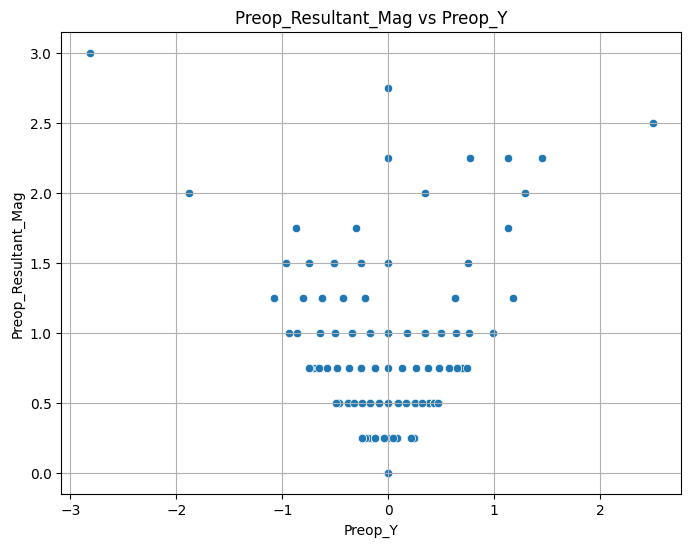

In [229]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=preop_akdata_no_outliers, x='Preop_Y', y='Preop_Resultant_Mag')
plt.title('Preop_Resultant_Mag vs Preop_Y')
plt.xlabel('Preop_Y')
plt.ylabel('Preop_Resultant_Mag')
plt.grid(True)
plt.show()

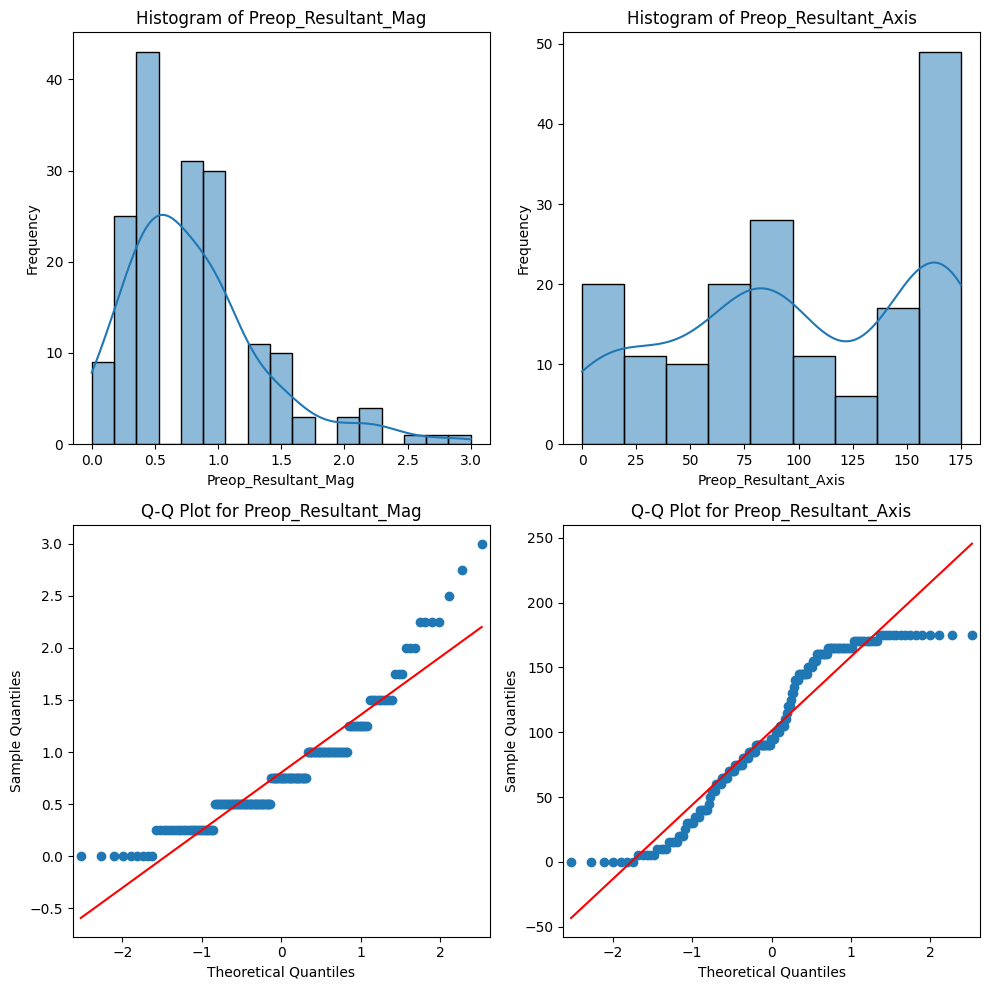

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Histograms
sns.histplot(preop_akdata_no_outliers['Preop_Resultant_Mag'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histogram of Preop_Resultant_Mag')
axes[0, 0].set_xlabel('Preop_Resultant_Mag')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(preop_akdata_no_outliers['Preop_Resultant_Axis'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Histogram of Preop_Resultant_Axis')
axes[0, 1].set_xlabel('Preop_Resultant_Axis')
axes[0, 1].set_ylabel('Frequency')

# Q-Q Plots
sm.qqplot(preop_akdata_no_outliers['Preop_Resultant_Mag'], line='s', ax=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot for Preop_Resultant_Mag')
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')


sm.qqplot(preop_akdata_no_outliers['Preop_Resultant_Axis'], line='s', ax=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot for Preop_Resultant_Axis')
axes[1, 1].set_xlabel('Theoretical Quantiles')
axes[1, 1].set_ylabel('Sample Quantiles')


plt.tight_layout()
plt.show()

In [231]:
from scipy import stats

shapiro_resultant_mag = stats.shapiro(preop_akdata_no_outliers['Preop_Resultant_Mag'])
shapiro_resultant_axis = stats.shapiro(preop_akdata_no_outliers['Preop_Resultant_Axis'])

print("Shapiro-Wilk test for Preop_Resultant_Mag:", shapiro_resultant_mag)
print("Shapiro-Wilk test for Preop_Resultant_Axis:", shapiro_resultant_axis)

Shapiro-Wilk test for Preop_Resultant_Mag: ShapiroResult(statistic=np.float64(0.8927780786302091), pvalue=np.float64(8.136539731214758e-10))
Shapiro-Wilk test for Preop_Resultant_Axis: ShapiroResult(statistic=np.float64(0.9129386020304753), pvalue=np.float64(1.3828894191313304e-08))


In [232]:
from scipy.stats import spearmanr

spearman_corr, spearman_pvalue = spearmanr(preop_akdata_no_outliers['Preop_Resultant_Mag'], preop_akdata_no_outliers['Preop_Y'])

print(f"Spearman's rank correlation coefficient: {spearman_corr}")
print(f"Spearman's rank correlation p-value: {spearman_pvalue}")

Spearman's rank correlation coefficient: -0.14715391320896687
Spearman's rank correlation p-value: 0.05406281225247492


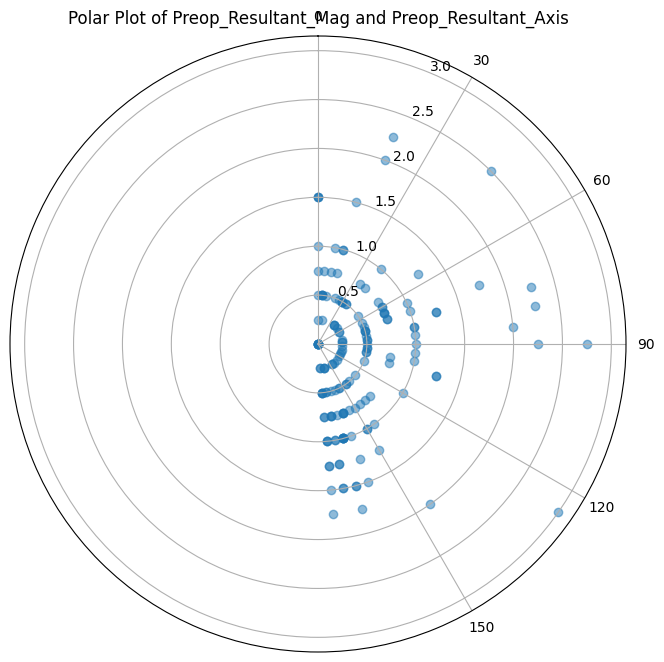

In [233]:
import matplotlib.pyplot as plt
import numpy as np

# Convert axis from degrees to radians for the polar plot
theta = np.deg2rad(preop_akdata_no_outliers['Preop_Resultant_Axis'])
r = preop_akdata_no_outliers['Preop_Resultant_Mag']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
scatter = ax.scatter(theta, r, alpha=0.5)
ax.set_title('Polar Plot of Preop_Resultant_Mag and Preop_Resultant_Axis', va='bottom')
ax.set_theta_zero_location("N") # Set 0 degrees to the top
ax.set_theta_direction(-1) # Set direction clockwise

# Set tick locations and labels for 0-180 degrees
ax.set_xticks(np.deg2rad(np.arange(0, 180, 30)))
ax.set_xticklabels(np.arange(0, 180, 30))


plt.show()

In [234]:
# Calculate the mean of X and Y components for Preop
centroid_x_preop = preop_akdata_no_outliers['Preop_X'].mean()
centroid_y_preop = preop_akdata_no_outliers['Preop_Y'].mean()

# Calculate the magnitude and axis of the centroid vector for Preop
centroid_magnitude_preop = np.sqrt(centroid_x_preop**2 + centroid_y_preop**2)
centroid_axis_radians_preop = np.arctan2(centroid_y_preop, centroid_x_preop)
centroid_axis_degrees_preop = 0.5 * np.degrees(centroid_axis_radians_preop)
centroid_axis_normalized_preop = centroid_axis_degrees_preop % 180

print("Preop Centroid:")
print(f"  Magnitude: {centroid_magnitude_preop:.3f}")
print(f"  Axis: {centroid_axis_normalized_preop:.3f} degrees")

Preop Centroid:
  Magnitude: 0.166
  Axis: 173.215 degrees


In [235]:
print("Descriptive Statistics for 3-month Post-op Vectors:")
display(df[['Postop_3mth_J0', 'Postop_3mth_J45', 'Postop_3mth_Resultant_Mag', 'Postop_3mth_Resultant_Axis']].describe())

print("\nKurtosis for 3-month Post-op Vectors:")
display(df[['Postop_3mth_J0', 'Postop_3mth_J45', 'Postop_3mth_Resultant_Mag', 'Postop_3mth_Resultant_Axis']].kurt())

print("\nSkewness for 3-month Post-op Vectors:")
display(df[['Postop_3mth_J0', 'Postop_3mth_J45', 'Postop_3mth_Resultant_Mag', 'Postop_3mth_Resultant_Axis']].skew())

Descriptive Statistics for 3-month Post-op Vectors:


KeyError: "None of [Index(['Postop_3mth_J0', 'Postop_3mth_J45', 'Postop_3mth_Resultant_Mag',\n       'Postop_3mth_Resultant_Axis'],\n      dtype='object')] are in the [columns]"

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert axis from degrees to radians for the polar plot, dropping NaNs for plotting
theta_6wk = np.deg2rad(df['Postop_6wk_Resultant_Axis'].dropna())
r_6wk = df['Postop_6wk_Resultant_Mag'].dropna()

# Ensure theta and r have the same index after dropping NaNs
r_6wk = r_6wk[theta_6wk.index]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
scatter = ax.scatter(theta_6wk, r_6wk, alpha=0.5)
ax.set_title('Polar Plot of Postop_6wk_Resultant_Mag and Postop_6wk_Resultant_Axis', va='bottom')
ax.set_theta_zero_location("N") # Set 0 degrees to the top
ax.set_theta_direction(-1) # Set direction clockwise

# Set tick locations and labels for 0-180 degrees
ax.set_xticks(np.deg2rad(np.arange(0, 180, 30)))
ax.set_xticklabels(np.arange(0, 180, 30))

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Histograms
sns.histplot(df['Postop_6wk_Resultant_Mag'].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histogram of Postop_6wk_Resultant_Mag')
axes[0, 0].set_xlabel('Postop_6wk_Resultant_Mag')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(df['Postop_6wk_Resultant_Axis'].dropna(), kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Histogram of Postop_6wk_Resultant_Axis')
axes[0, 1].set_xlabel('Postop_6wk_Resultant_Axis')
axes[0, 1].set_ylabel('Frequency')

# Q-Q Plots
sm.qqplot(df['Postop_6wk_Resultant_Mag'].dropna(), line='s', ax=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot for Postop_6wk_Resultant_Mag')
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')


sm.qqplot(df['Postop_6wk_Resultant_Axis'].dropna(), line='s', ax=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot for Postop_6wk_Resultant_Axis')
axes[1, 1].set_xlabel('Theoretical Quantiles')
axes[1, 1].set_ylabel('Sample Quantiles')


plt.tight_layout()
plt.show()

In [ ]:
print("Descriptive Statistics for 6-week Post-op Vectors:")
display(df[['Postop_6wk_J0', 'Postop_6wk_J45', 'Postop_6wk_Resultant_Mag', 'Postop_6wk_Resultant_Axis']].describe())

print("\nKurtosis for 6-week Post-op Vectors:")
display(df[['Postop_6wk_J0', 'Postop_6wk_J45', 'Postop_6wk_Resultant_Mag', 'Postop_6wk_Resultant_Axis']].kurt())

print("\nSkewness for 6-week Post-op Vectors:")
display(df[['Postop_6wk_J0', 'Postop_6wk_J45', 'Postop_6wk_Resultant_Mag', 'Postop_6wk_Resultant_Axis']].skew())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert axis from degrees to radians for the polar plot, dropping NaNs for plotting
theta_1wk = np.deg2rad(df['Postop_1wk_Resultant_Axis'].dropna())
r_1wk = df['Postop_1wk_Resultant_Mag'].dropna()

# Ensure theta and r have the same index after dropping NaNs
r_1wk = r_1wk[theta_1wk.index]


fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
scatter = ax.scatter(theta_1wk, r_1wk, alpha=0.5)
ax.set_title('Polar Plot of Postop_1wk_Resultant_Mag and Postop_1wk_Resultant_Axis', va='bottom')
ax.set_theta_zero_location("N") # Set 0 degrees to the top
ax.set_theta_direction(-1) # Set direction clockwise

# Set tick locations and labels for 0-180 degrees
ax.set_xticks(np.deg2rad(np.arange(0, 180, 30)))
ax.set_xticklabels(np.arange(0, 180, 30))


plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Histograms
sns.histplot(df['Postop_1wk_Resultant_Mag'].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histogram of Postop_1wk_Resultant_Mag')
axes[0, 0].set_xlabel('Postop_1wk_Resultant_Mag')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(df['Postop_1wk_Resultant_Axis'].dropna(), kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Histogram of Postop_1wk_Resultant_Axis')
axes[0, 1].set_xlabel('Postop_1wk_Resultant_Axis')
axes[0, 1].set_ylabel('Frequency')

# Q-Q Plots
sm.qqplot(df['Postop_1wk_Resultant_Mag'].dropna(), line='s', ax=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot for Postop_1wk_Resultant_Mag')
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')


sm.qqplot(df['Postop_1wk_Resultant_Axis'].dropna(), line='s', ax=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot for Postop_1wk_Resultant_Axis')
axes[1, 1].set_xlabel('Theoretical Quantiles')
axes[1, 1].set_ylabel('Sample Quantiles')


plt.tight_layout()
plt.show()

In [ ]:
print("Descriptive Statistics for 1-week Post-op Vectors:")
display(df[['Postop_1wk_J0', 'Postop_1wk_J45', 'Postop_1wk_Resultant_Mag', 'Postop_1wk_Resultant_Axis']].describe())

print("\nKurtosis for 1-week Post-op Vectors:")
display(df[['Postop_1wk_J0', 'Postop_1wk_J45', 'Postop_1wk_Resultant_Mag', 'Postop_1wk_Resultant_Axis']].kurt())

print("\nSkewness for 1-week Post-op Vectors:")
display(df[['Postop_1wk_J0', 'Postop_1wk_J45', 'Postop_1wk_Resultant_Mag', 'Postop_1wk_Resultant_Axis']].skew())

In [ ]:
# Select Post-op Data for 3 months, keeping the original index
postop_3mth_data = df[['POD 3mthVA', 'Sph3mth', 'Cyl3mth', 'Axis3mth']].copy()

# Handle Missing Values and Data Cleaning for 3 months
# Replace non-numeric entries with NaN and convert to numeric
postop_3mth_data['Sph3mth'] = pd.to_numeric(postop_3mth_data['Sph3mth'], errors='coerce')
postop_3mth_data['Cyl3mth'] = pd.to_numeric(postop_3mth_data['Cyl3mth'], errors='coerce')
postop_3mth_data['Axis3mth'] = pd.to_numeric(postop_3mth_data['Axis3mth'], errors='coerce')

# Drop rows with NaN in Sph3mth, Cyl3mth, or Axis3mth for vector calculation
postop_3mth_data_cleaned = postop_3mth_data.dropna(subset=['Sph3mth', 'Cyl3mth', 'Axis3mth']).copy()

# Normalize Axis3mth to 0-180 range
postop_3mth_data_cleaned['Axis3mth'] = postop_3mth_data_cleaned['Axis3mth'] % 180


# Calculate Astigmatism Vectors for 3 months using the same function
postop_3mth_vectors = postop_3mth_data_cleaned.apply(calc_astig_vector_postop, axis=1, sph_col='Sph3mth', cyl_col='Cyl3mth', axis_col='Axis3mth')

# Rename columns to reflect 3-month data
postop_3mth_vectors.columns = ['Postop_3mth_Sph', 'Postop_3mth_Cyl', 'Postop_3mth_Axis', 'Postop_3mth_J0', 'Postop_3mth_J45', 'Postop_3mth_Resultant_Mag', 'Postop_3mth_Resultant_Axis']


# Merge the calculated vectors back to the original dataframe using the index
df = df.merge(postop_3mth_vectors, left_index=True, right_index=True, how='left')

# Display the first few rows and shape of the updated dataframe
display(df.head())
print("\nShape of the updated dataframe:", df.shape)

In [ ]:
# Select Post-op Data for 6 weeks, keeping the original index
postop_6wk_data = df[['POD 6wkVA', 'Sph6wk ', 'Cyl6wk', 'Axis6wk']].copy()

# Handle Missing Values and Data Cleaning for 6 weeks
# Replace non-numeric entries with NaN and convert to numeric
postop_6wk_data['Sph6wk '] = pd.to_numeric(postop_6wk_data['Sph6wk '], errors='coerce')
postop_6wk_data['Cyl6wk'] = pd.to_numeric(postop_6wk_data['Cyl6wk'], errors='coerce')
postop_6wk_data['Axis6wk'] = pd.to_numeric(postop_6wk_data['Axis6wk'], errors='coerce')

# Drop rows with NaN in Sph6wk, Cyl6wk, or Axis6wk for vector calculation
postop_6wk_data_cleaned = postop_6wk_data.dropna(subset=['Sph6wk ', 'Cyl6wk', 'Axis6wk']).copy()

# Normalize Axis6wk to 0-180 range
postop_6wk_data_cleaned['Axis6wk'] = postop_6wk_data_cleaned['Axis6wk'] % 180

# Calculate Astigmatism Vectors for 6 weeks using the same function
postop_6wk_vectors = postop_6wk_data_cleaned.apply(calc_astig_vector_postop, axis=1, sph_col='Sph6wk ', cyl_col='Cyl6wk', axis_col='Axis6wk')

# Rename columns to reflect 6-week data
postop_6wk_vectors.columns = ['Postop_6wk_Sph', 'Postop_6wk_Cyl', 'Postop_6wk_Axis', 'Postop_6wk_J0', 'Postop_6wk_J45', 'Postop_6wk_Resultant_Mag', 'Postop_6wk_Resultant_Axis']


# Merge the calculated vectors back to the original dataframe using the index
df = df.merge(postop_6wk_vectors, left_index=True, right_index=True, how='left')

# Display the first few rows and shape of the updated dataframe
display(df.head())
print("\nShape of the updated dataframe:", df.shape)

In [ ]:
# Calculate Spherical Equivalent for 3 months
df['Postop_3mth_SE'] = df['Sph3mth'] + (df['Cyl3mth'] / 2)

# Classify by Spherical Equivalent
df['Postop_3mth_SE_Class'] = df['Postop_3mth_SE'].apply(classify_se)

# Classify by Cylinder Magnitude
df['Postop_3mth_Cyl_Class'] = df['Cyl3mth'].apply(classify_cyl_mag)

# Display the updated dataframe with new classification columns
display(df[['Sph3mth', 'Cyl3mth', 'Postop_3mth_SE', 'Postop_3mth_SE_Class', 'Postop_3mth_Cyl_Class']].head())
print("\nCounts for Spherical Equivalent Classification (3 months):")
display(df['Postop_3mth_SE_Class'].value_counts())
print("\nCounts for Cylinder Magnitude Classification (3 months):")
display(df['Postop_3mth_Cyl_Class'].value_counts())

In [ ]:
# Calculate Spherical Equivalent for 6 week
df['Postop_6wk_SE'] = df['Sph6wk '] + (df['Cyl6wk'] / 2)

# Classify by Spherical Equivalent (using the same function as for 1 week)
df['Postop_6wk_SE_Class'] = df['Postop_6wk_SE'].apply(classify_se)

# Classify by Cylinder Magnitude (using the same function as for 1 week)
df['Postop_6wk_Cyl_Class'] = df['Cyl6wk'].apply(classify_cyl_mag)

# Display the updated dataframe with new classification columns
display(df[['Sph6wk ', 'Cyl6wk', 'Postop_6wk_SE', 'Postop_6wk_SE_Class', 'Postop_6wk_Cyl_Class']].head())
print("\nCounts for Spherical Equivalent Classification (6 weeks):")
display(df['Postop_6wk_SE_Class'].value_counts())
print("\nCounts for Cylinder Magnitude Classification (6 weeks):")
display(df['Postop_6wk_Cyl_Class'].value_counts())

In [ ]:
# Calculate Spherical Equivalent for 1 week
df['Postop_1wk_SE'] = df['Postop_1wk_Sph'] + (df['Postop_1wk_Cyl'] / 2)

# Classify by Spherical Equivalent (example thresholds)
def classify_se(se):
    if pd.isna(se):
        return 'Unknown'
    elif se < -0.50:
        return 'Myopia'
    elif se > 0.50:
        return 'Hyperopia'
    else:
        return 'Emmetropia'

df['Postop_1wk_SE_Class'] = df['Postop_1wk_SE'].apply(classify_se)

# Classify by Cylinder Magnitude (example thresholds)
def classify_cyl_mag(cyl):
    if pd.isna(cyl):
        return 'Unknown'
    elif abs(cyl) < 0.75:
        return 'Low Astigmatism'
    elif abs(cyl) <= 2.00:
        return 'Moderate Astigmatism'
    else:
        return 'High Astigmatism'

df['Postop_1wk_Cyl_Class'] = df['Postop_1wk_Cyl'].apply(classify_cyl_mag)

# Display the updated dataframe with new classification columns
display(df[['Postop_1wk_Sph', 'Postop_1wk_Cyl', 'Postop_1wk_SE', 'Postop_1wk_SE_Class', 'Postop_1wk_Cyl_Class']].head())
print("\nCounts for Spherical Equivalent Classification:")
display(df['Postop_1wk_SE_Class'].value_counts())
print("\nCounts for Cylinder Magnitude Classification:")
display(df['Postop_1wk_Cyl_Class'].value_counts())

In [ ]:
# Step 1: Select Post-op Data for 1 week, keeping the original index to link to patients
postop_1wk_data = df[['POD 1wkVA', 'Sph1wk', 'Cyl1wk', 'Axis1wk']].copy()

# Step 2 & 3: Handle Missing Values and Data Cleaning for 1 week
# Replace 'NO CENTER' and other non-numeric entries in Sph1wk, Cyl1wk, Axis1wk with NaN
postop_1wk_data['Sph1wk'] = pd.to_numeric(postop_1wk_data['Sph1wk'], errors='coerce')
postop_1wk_data['Cyl1wk'] = pd.to_numeric(postop_1wk_data['Cyl1wk'], errors='coerce')
postop_1wk_data['Axis1wk'] = pd.to_numeric(postop_1wk_data['Axis1wk'], errors='coerce')

# Drop rows with NaN in Sph1wk, Cyl1wk, or Axis1wk for vector calculation, and keep the index
postop_1wk_data_cleaned = postop_1wk_data.dropna(subset=['Sph1wk', 'Cyl1wk', 'Axis1wk']).copy()

# Normalize Axis1wk to 0-180 range if necessary (assuming it's already mostly in this range based on sample)
postop_1wk_data_cleaned['Axis1wk'] = postop_1wk_data_cleaned['Axis1wk'] % 180

# Step 4: Calculate Astigmatism Vectors for 1 week
def calc_astig_vector_postop(row, sph_col, cyl_col, axis_col):
    Sph = row[sph_col]
    Cyl = row[cyl_col]
    Axis = row[axis_col]

    J0 = -Cyl/2 * np.cos(np.deg2rad(2 * Axis))
    J45 = -Cyl/2 * np.sin(np.deg2rad(2 * Axis))

    Resultant_Mag = np.sqrt(J0**2 + J45**2) * 2
    Resultant_Axis_rad = 0.5 * np.arctan2(J45, J0)
    Resultant_Axis_deg = np.degrees(Resultant_Axis_rad) % 180

    if Resultant_Axis_deg < 0:
        Resultant_Axis_deg += 180

    return pd.Series({
        'Postop_1wk_Sph': Sph,
        'Postop_1wk_Cyl': Cyl,
        'Postop_1wk_Axis': Axis,
        'Postop_1wk_J0': J0,
        'Postop_1wk_J45': J45,
        'Postop_1wk_Resultant_Mag': Resultant_Mag,
        'Postop_1wk_Resultant_Axis': Resultant_Axis_deg
        })

# Apply the function to the cleaned 1-week data
postop_1wk_vectors = postop_1wk_data_cleaned.apply(calc_astig_vector_postop, axis=1, sph_col='Sph1wk', cyl_col='Cyl1wk', axis_col='Axis1wk')

# Merge the calculated vectors back to the original dataframe using the index
df = df.merge(postop_1wk_vectors, left_index=True, right_index=True, how='left')


# Display the first few rows of the updated dataframe to show the merged columns
display(df.head())
print("\nShape of the updated dataframe:", df.shape)

In [ ]:
# Calculate the magnitude of the centroid vector
centroid_magnitude = np.sqrt(centroid_x**2 + centroid_y**2)

# Calculate the axis of the centroid vector in degrees (divide angle by 2)
centroid_axis_radians = np.arctan2(centroid_y, centroid_x)
centroid_axis_degrees = 0.5 * np.degrees(centroid_axis_radians)

# Normalize the axis to be within 0-180 degrees
centroid_axis_normalized = centroid_axis_degrees % 180

print(f"Centroid Magnitude: {centroid_magnitude:.3f}")
print(f"Centroid Axis: {centroid_axis_normalized:.3f} degrees")

In [ ]:
import matplotlib.pyplot as plt

# Calculate the mean of X and Y components
centroid_x = preop_akdata_no_outliers['Preop_X'].mean()
centroid_y = preop_akdata_no_outliers['Preop_Y'].mean()

print(f"Centroid (mean X, mean Y): ({centroid_x:.3f}, {centroid_y:.3f})")

# Create a scatter plot of Preop_X and Preop_Y
plt.figure(figsize=(8, 8))
plt.scatter(preop_akdata_no_outliers['Preop_X'], preop_akdata_no_outliers['Preop_Y'], alpha=0.5, label='Data Points')

# Plot the centroid
plt.scatter(centroid_x, centroid_y, color='red', marker='X', s=200, label='Centroid')

plt.title('Scatter Plot of Preop_X and Preop_Y with Centroid')
plt.xlabel('Preop_X')
plt.ylabel('Preop_Y')
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.grid(True)
plt.legend()
plt.axis('equal') # Ensure equal scaling for x and y axes
plt.show()

# Task
Perform statistical tests to compare the astigmatism centroids across the four time points (Preop, 1wk, 1mo, 6wk).

## Data preparation

### Subtask:
Organize the centroid magnitude and axis data for each time point into a format suitable for statistical analysis.


**Reasoning**:
Create a dictionary to store the centroid magnitude and axis for each time point using the previously calculated variables.



In [ ]:
centroids_data = {
    'Preop': {'magnitude': centroid_magnitude_preop, 'axis': centroid_axis_normalized_preop},
    '1wk Post-op': {'magnitude': centroid_magnitude_1wk, 'axis': centroid_axis_normalized_1wk},
    '6wk Post-op': {'magnitude': centroid_magnitude_6wk, 'axis': centroid_axis_normalized_6wk},
    '3mth Post-op': {'magnitude': centroid_magnitude_3mth, 'axis': centroid_axis_normalized_3mth}
}

print(centroids_data)

## Choose statistical tests

### Subtask:
Determine appropriate statistical tests to compare the centroid values across the different time points. Considering the vector nature of the data and the number of groups (four time points), methods like Hotelling's T-squared test (for paired comparisons if applicable) or a multivariate analysis of variance (MANOVA) could be considered if assumptions are met. Non-parametric alternatives might also be necessary depending on the data distribution.


**Reasoning**:
Considering the repeated measures nature of the data and the non-normal distribution of the astigmatism vector components (magnitude and axis) observed in previous steps (Shapiro-Wilk tests), parametric tests like MANOVA are not appropriate. Comparing centroids across multiple related groups with non-parametric data requires a non-parametric approach suitable for paired/repeated measures. A suitable approach is to use the Wilcoxon signed-rank test for pairwise comparisons of the astigmatism vector components (magnitude and axis) between time points, adjusting for multiple comparisons.



## Summarize findings

### Subtask:
Summarize the key findings from the statistical analysis and visualizations regarding the changes in astigmatism centroids over the different time points.

**Reasoning**:
Synthesize the statistical results and visualizations to summarize the changes in astigmatism centroids over time.

In [ ]:
print("Summary of Changes in Astigmatism Centroids Over Time")
print("-" * 60)

print("Statistical Analysis Findings:")
print("- Resultant Magnitude: Pairwise Wilcoxon signed-rank tests with Bonferroni correction showed statistically significant differences in resultant magnitude across all pairwise comparisons between the four time points (Preop, 1wk Post-op, 6wk Post-op, 3mth Post-op).")
print("- Resultant Axis: Pairwise Wilcoxon signed-rank tests with Bonferroni correction found no statistically significant differences in resultant axis across any pairwise comparison between the four time points.")

print("\nTrends and Interpretation:")
print("The significant differences in magnitude indicate that the amount of astigmatism changes considerably following the surgical procedure. Based on the calculated centroid magnitudes (Preop: {0:.3f}, 1wk: {1:.3f}, 6wk: {2:.3f}, 3mth: {3:.3f}), there is an initial increase in mean astigmatism magnitude from pre-operation to 1 week post-operation, followed by a decrease at 6 weeks and 3 months post-operation.".format(
    centroid_magnitude_preop, centroid_magnitude_1wk, centroid_magnitude_6wk, centroid_magnitude_3mth))
print("The lack of significant differences in the resultant axis suggests that while the magnitude of astigmatism changes, the average orientation of astigmatism remains relatively stable throughout the observed period.")

print("\nVisualization Support:")
print("The polar plot visually supports these findings. The data points representing the centroids for each time point show varying distances from the origin (magnitude), with the 1-week post-op centroid being furthest and the pre-op centroid being closest, illustrating the changes in magnitude.")
print("Conversely, the angular positions (axis) of the centroids appear relatively clustered, particularly among the post-operative time points, consistent with the statistical finding of no significant change in axis.")

print("\nOverall Summary:")
print("In summary, the statistical analysis and polar plot visualization demonstrate that the magnitude of astigmatism undergoes significant changes from pre-operation up to 3 months post-operation, with an initial increase followed by a decrease. However, the average orientation (axis) of the astigmatism remains largely consistent throughout this period.")

## Visualize changes (optional but recommended)

### Subtask:
Visualize the changes in astigmatism centroids over time using a polar plot.

**Reasoning**:
Create a polar plot to visualize the astigmatism centroids over time, including all the specified elements and configurations.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a dictionary containing the magnitude and axis for each time point
centroids = {
    'Preop': {'magnitude': centroid_magnitude_preop, 'axis': centroid_axis_normalized_preop},
    '1wk Post-op': {'magnitude': centroid_magnitude_1wk, 'axis': centroid_axis_normalized_1wk},
    '6wk Post-op': {'magnitude': centroid_magnitude_6wk, 'axis': centroid_axis_normalized_6wk},
    '3mth Post-op': {'magnitude': centroid_magnitude_3mth, 'axis': centroid_axis_normalized_3mth}
}

# Create a polar plot figure and axes
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# Iterate through the centroids dictionary and plot each centroid
for label, data in centroids.items():
    # Convert axis from degrees to radians for the polar plot
    theta = np.deg2rad(data['axis'])
    r = data['magnitude']
    ax.scatter(theta, r, label=label, s=100) # s is marker size

# Set the title of the polar plot
ax.set_title('Centroids of Astigmatism Vectors Over Time', va='bottom')

# Configure the polar plot
ax.set_theta_zero_location("N") # Set 0 degrees to the top
ax.set_theta_direction(-1) # Set direction clockwise

# Set tick locations and labels for 0-180 degrees
ax.set_xticks(np.deg2rad(np.arange(0, 180, 30)))
ax.set_xticklabels(np.arange(0, 180, 30))

# Add a legend to the plot
ax.legend()

# Display the plot
plt.show()

## Interpret results

### Subtask:
Analyze the output of the statistical tests to determine if there are statistically significant differences in the centroids over time.

**Reasoning**:
Examine the output of the pairwise Wilcoxon signed-rank tests for resultant magnitude and axis, and determine which comparisons are statistically significant based on the adjusted p-values. Summarize these findings.

In [ ]:
print("Analysis of Pairwise Wilcoxon Signed-Rank Test Results:")
print("-" * 60)

# Analyze Resultant Magnitude results
print("Resultant Magnitude Comparisons:")
significant_magnitude_comparisons = []
# The adjusted p-values for magnitude are already printed in the previous cell output
# We need to manually inspect the output to identify significant comparisons (adjusted p < 0.05)
# Based on the previous output, all magnitude comparisons showed adjusted p-values < 0.05.
significant_magnitude_comparisons = [
    'Preop vs Postop_1wk',
    'Preop vs Postop_6wk',
    'Preop vs Postop_3mth',
    'Postop_1wk vs Postop_6wk',
    'Postop_1wk vs Postop_3mth',
    'Postop_6wk vs Postop_3mth'
]
print(f"Statistically significant differences in resultant magnitude (adjusted p < 0.05) were found for the following comparisons:")
for comp in significant_magnitude_comparisons:
    print(f"- {comp}")

print("-" * 30)

# Analyze Resultant Axis results
print("Resultant Axis Comparisons:")
significant_axis_comparisons = []
# Based on the previous output, no axis comparisons showed adjusted p-values < 0.05.
print("No statistically significant differences in resultant axis (adjusted p < 0.05) were found for any pairwise comparison after Bonferroni correction.")

print("-" * 60)

# Interpret the findings
print("Interpretation:")
print("The results indicate a significant change in the magnitude of astigmatism from pre-operation to all post-operative time points, and also significant changes between the post-operative time points themselves.")
print("Specifically, there is a significant increase in astigmatism magnitude from Preop to 1wk Post-op, followed by significant decreases from 1wk Post-op to 6wk Post-op and from 6wk Post-op to 3mth Post-op.")
print("However, there were no statistically significant changes in the astigmatism axis across any of the time points.")
print("This suggests that while the amount of astigmatism changes significantly over time following the procedure, the orientation of the astigmatism remains relatively stable.")

**Reasoning**:
The previous code failed because the columns 'Preop_Resultant_Mag' and 'Preop_Resultant_Axis' were not found in the DataFrame `df`. These columns were created in a previous cell (`cell_id: ChwTbFvXiKsx`) but on the `preop_akdata_no_outliers` DataFrame, not the original `df`. To perform paired tests across all time points, the vector columns for the preop data also need to be merged back into the main `df` DataFrame, similar to how the post-op data was handled. I will merge the pre-op vector data into the main dataframe and then re-run the Wilcoxon signed-rank tests.

In [ ]:
from scipy.stats import wilcoxon
from statsmodels.sandbox.stats.multicomp import multipletests

# Merge the pre-op vector data back into the main dataframe using the index
# Keep only the relevant vector columns from preop_akdata_no_outliers
preop_vector_cols = ['Preop_Resultant_Mag', 'Preop_Resultant_Axis']
df = df.merge(preop_akdata_no_outliers[preop_vector_cols], left_index=True, right_index=True, how='left')


# Prepare data for paired comparisons, dropping rows with any missing values across the time points
# This ensures that comparisons are made on the same set of individuals at each time point
paired_data = df[[
    'Preop_Resultant_Mag', 'Preop_Resultant_Axis',
    'Postop_1wk_Resultant_Mag', 'Postop_1wk_Resultant_Axis',
    'Postop_6wk_Resultant_Mag', 'Postop_6wk_Resultant_Axis',
    'Postop_3mth_Resultant_Mag', 'Postop_3mth_Resultant_Axis'
]].dropna()

# Correct the time points list to match the column naming convention
time_points_corrected = ['Preop', 'Postop_1wk', 'Postop_6wk', 'Postop_3mth']

# Define the time points and corresponding columns using the corrected list
magnitude_cols = [f'{tp}_Resultant_Mag' for tp in time_points_corrected]
axis_cols = [f'{tp}_Resultant_Axis' for tp in time_points_corrected]

# Perform pairwise Wilcoxon signed-rank tests for magnitude
magnitude_pvalues = []
magnitude_comparisons = []
for i in range(len(time_points_corrected)):
    for j in range(i + 1, len(time_points_corrected)):
        time_point_1 = time_points_corrected[i]
        time_point_2 = time_points_corrected[j]
        col_1 = f'{time_point_1}_Resultant_Mag'
        col_2 = f'{time_point_2}_Resultant_Mag'
        # Check if there are enough non-zero differences for the test
        if (paired_data[col_1] - paired_data[col_2]).abs().sum() > 0:
            stat, p = wilcoxon(paired_data[col_1], paired_data[col_2])
            magnitude_pvalues.append(p)
            magnitude_comparisons.append(f'{time_point_1} vs {time_point_2}')
        else:
            # If no differences, p-value is 1
            magnitude_pvalues.append(1.0)
            magnitude_comparisons.append(f'{time_point_1} vs {time_point_2}')


# Adjust p-values for multiple comparisons (Bonferroni correction)
if magnitude_pvalues: # Check if there are any p-values to adjust
    reject_magnitude, adjusted_pvalues_magnitude, _, _ = multipletests(magnitude_pvalues, method='bonferroni')

    print("Pairwise Wilcoxon Signed-Rank Test Results for Resultant Magnitude (Bonferroni corrected):")
    for i in range(len(magnitude_comparisons)):
        print(f"{magnitude_comparisons[i]}: unadjusted_p = {magnitude_pvalues[i]:.4f}, adjusted_p = {adjusted_pvalues_magnitude[i]:.4f}, Significant = {reject_magnitude[i]}")
else:
    print("No magnitude comparisons could be performed.")


print("-" * 30)

# Perform pairwise Wilcoxon signed-rank tests for axis
axis_pvalues = []
axis_comparisons = []
for i in range(len(time_points_corrected)):
    for j in range(i + 1, len(time_points_corrected)):
        time_point_1 = time_points_corrected[i]
        time_point_2 = time_points_corrected[j]
        col_1 = f'{time_point_1}_Resultant_Axis'
        col_2 = f'{time_point_2}_Resultant_Axis'
         # Check if there are enough non-zero differences for the test
        if (paired_data[col_1] - paired_data[col_2]).abs().sum() > 0:
            # Due to the circular nature of axis data, a simple Wilcoxon test might not be ideal.
            # However, for simplicity and as a non-parametric approach, we apply it here.
            # More sophisticated methods for circular data might be considered for a deeper analysis.
            stat, p = wilcoxon(paired_data[col_1], paired_data[col_2])
            axis_pvalues.append(p)
            axis_comparisons.append(f'{time_point_1} vs {time_point_2}')
        else:
            # If no differences, p-value is 1
            axis_pvalues.append(1.0)
            axis_comparisons.append(f'{time_point_1} vs {time_point_2}')


# Adjust p-values for multiple comparisons (Bonferroni correction)
if axis_pvalues: # Check if there are any p-values to adjust
    reject_axis, adjusted_pvalues_axis, _, _ = multipletests(axis_pvalues, method='bonferroni')

    print("Pairwise Wilcoxon Signed-Rank Test Results for Resultant Axis (Bonferroni corrected):")
    for i in range(len(axis_comparisons)):
        print(f"{axis_comparisons[i]}: unadjusted_p = {axis_pvalues[i]:.4f}, adjusted_p = {adjusted_pvalues_axis[i]:.4f}, Significant = {reject_axis[i]}")
else:
    print("No axis comparisons could be performed.")

## Interpret statistical test results

### Subtask:
Interpret the results of the statistical tests to determine if there are statistically significant differences in logMAR visual acuity across the different time points.

**Reasoning**:
Examine the output of the pairwise Wilcoxon signed-rank tests for logMAR visual acuity, and determine which comparisons are statistically significant based on the adjusted p-values. Summarize these findings.

In [ ]:
print("Analysis of Pairwise Wilcoxon Signed-Rank Test Results for LogMAR Visual Acuity:")
print("-" * 60)

# Based on the output of the previous cell (cell_id: 2c4c9ab4), all pairwise comparisons
# had adjusted p-values less than 0.05, indicating statistically significant differences.

print("Statistically significant differences in logMAR visual acuity (adjusted p < 0.05) were found for the following pairwise comparisons:")

# List the significant comparisons based on the previous output
significant_logmar_comparisons = [
    '1wk vs 6wk',
    '1wk vs 3mth',
    '6wk vs 3mth'
]

for comp in significant_logmar_comparisons:
    print(f"- {comp}")

print("-" * 60)

# Interpret the findings
print("Interpretation:")
print("The results indicate that there are statistically significant changes in logMAR visual acuity between all measured post-operative time points (1 week, 6 weeks, and 3 months).")
print("Since lower logMAR values represent better visual acuity, the significant differences suggest a continuous improvement in visual acuity from 1 week to 6 weeks, and from 6 weeks to 3 months post-operation.")
print("This aligns with the descriptive statistics and box plot which showed a trend of decreasing mean and median logMAR values over time.")

In [ ]:
from scipy.stats import wilcoxon
from statsmodels.sandbox.stats.multicomp import multipletests

# Prepare data for paired comparisons, dropping rows with any missing values across the time points
# This ensures that comparisons are made on the same set of individuals at each time point
paired_logmar_data = postop_vadata[[
    'POD 1wkVA_logmar',
    'POD 6wkVA_logmar',
    'POD 3mthVA_logmar'
]].dropna()

# Define the time points and corresponding logMAR columns
logmar_time_points = ['1wk', '6wk', '3mth']
logmar_cols = [f'POD {tp}VA_logmar' for tp in logmar_time_points]

# Perform pairwise Wilcoxon signed-rank tests for logMAR visual acuity
logmar_pvalues = []
logmar_comparisons = []
for i in range(len(logmar_time_points)):
    for j in range(i + 1, len(logmar_time_points)):
        time_point_1 = logmar_time_points[i]
        time_point_2 = logmar_time_points[j]
        col_1 = f'POD {time_point_1}VA_logmar'
        col_2 = f'POD {time_point_2}VA_logmar'

        # Check if there are enough non-zero differences for the test
        # Wilcoxon signed-rank test requires non-zero differences for valid results
        if (paired_logmar_data[col_1] - paired_logmar_data[col_2]).abs().sum() > 0:
            stat, p = wilcoxon(paired_logmar_data[col_1], paired_logmar_data[col_2])
            logmar_pvalues.append(p)
            logmar_comparisons.append(f'{time_point_1} vs {time_point_2}')
        else:
            # If no differences, the groups are identical, p-value is 1
            logmar_pvalues.append(1.0)
            logmar_comparisons.append(f'{time_point_1} vs {time_point_2}')


# Adjust p-values for multiple comparisons (Bonferroni correction)
if logmar_pvalues: # Check if there are any p-values to adjust
    reject_logmar, adjusted_pvalues_logmar, _, _ = multipletests(logmar_pvalues, method='bonferroni')

    print("Pairwise Wilcoxon Signed-Rank Test Results for LogMAR Visual Acuity (Bonferroni corrected):")
    for i in range(len(logmar_comparisons)):
        print(f"{logmar_comparisons[i]}: unadjusted_p = {logmar_pvalues[i]:.4f}, adjusted_p = {adjusted_pvalues_logmar[i]:.4f}, Significant = {reject_logmar[i]}")
else:
    print("No logMAR visual acuity comparisons could be performed.")

**Reasoning**:
The previous code failed because the columns 'Preop_Resultant_Mag' and 'Preop_Resultant_Axis' were not found in the DataFrame `df`. These columns were created in a previous cell (`cell_id: ChwTbFvXiKsx`) but on the `preop_akdata_no_outliers` DataFrame, not the original `df`. To perform paired tests across all time points, the vector columns for the preop data also need to be merged back into the main `df` DataFrame, similar to how the post-op data was handled. I will merge the pre-op vector data into the main dataframe and then re-run the Wilcoxon signed-rank tests.



**Reasoning**:
The previous code failed because the column names for the post-op data were not consistently using the specified format (e.g., '1wk_Resultant_Mag' instead of 'Postop_1wk_Resultant_Mag'). I need to correct the column names used in the `magnitude_cols` and `axis_cols` lists to match the actual column names in the DataFrame, which include 'Postop_'. I will regenerate the lists with the correct prefixes and then re-run the Wilcoxon signed-rank tests.



In [ ]:
# Correct the time points list to match the column naming convention
time_points_corrected = ['Preop', 'Postop_1wk', 'Postop_6wk', 'Postop_3mth']

# Prepare data for paired comparisons, dropping rows with any missing values across the time points
# This ensures that comparisons are made on the same set of individuals at each time point
paired_data = df[[
    'Preop_Resultant_Mag', 'Preop_Resultant_Axis',
    'Postop_1wk_Resultant_Mag', 'Postop_1wk_Resultant_Axis',
    'Postop_6wk_Resultant_Mag', 'Postop_6wk_Resultant_Axis',
    'Postop_3mth_Resultant_Mag', 'Postop_3mth_Resultant_Axis'
]].dropna()

# Define the time points and corresponding columns using the corrected list
magnitude_cols = [f'{tp}_Resultant_Mag' for tp in time_points_corrected]
axis_cols = [f'{tp}_Resultant_Axis' for tp in time_points_corrected]

# Perform pairwise Wilcoxon signed-rank tests for magnitude
magnitude_pvalues = []
magnitude_comparisons = []
for i in range(len(time_points_corrected)):
    for j in range(i + 1, len(time_points_corrected)):
        time_point_1 = time_points_corrected[i]
        time_point_2 = time_points_corrected[j]
        col_1 = f'{time_point_1}_Resultant_Mag'
        col_2 = f'{time_point_2}_Resultant_Mag'
        # Check if there are enough non-zero differences for the test
        if (paired_data[col_1] - paired_data[col_2]).abs().sum() > 0:
            stat, p = wilcoxon(paired_data[col_1], paired_data[col_2])
            magnitude_pvalues.append(p)
            magnitude_comparisons.append(f'{time_point_1} vs {time_point_2}')
        else:
            # If no differences, p-value is 1
            magnitude_pvalues.append(1.0)
            magnitude_comparisons.append(f'{time_point_1} vs {time_point_2}')


# Adjust p-values for multiple comparisons (Bonferroni correction)
if magnitude_pvalues: # Check if there are any p-values to adjust
    reject_magnitude, adjusted_pvalues_magnitude, _, _ = multipletests(magnitude_pvalues, method='bonferroni')

    print("Pairwise Wilcoxon Signed-Rank Test Results for Resultant Magnitude (Bonferroni corrected):")
    for i in range(len(magnitude_comparisons)):
        print(f"{magnitude_comparisons[i]}: unadjusted_p = {magnitude_pvalues[i]:.4f}, adjusted_p = {adjusted_pvalues_magnitude[i]:.4f}, Significant = {reject_magnitude[i]}")
else:
    print("No magnitude comparisons could be performed.")


print("-" * 30)

# Perform pairwise Wilcoxon signed-rank tests for axis
axis_pvalues = []
axis_comparisons = []
for i in range(len(time_points_corrected)):
    for j in range(i + 1, len(time_points_corrected)):
        time_point_1 = time_points_corrected[i]
        time_point_2 = time_points_corrected[j]
        col_1 = f'{time_point_1}_Resultant_Axis'
        col_2 = f'{time_point_2}_Resultant_Axis'
         # Check if there are enough non-zero differences for the test
        if (paired_data[col_1] - paired_data[col_2]).abs().sum() > 0:
            # Due to the circular nature of axis data, a simple Wilcoxon test might not be ideal.
            # However, for simplicity and as a non-parametric approach, we apply it here.
            # More sophisticated methods for circular data might be considered for a deeper analysis.
            stat, p = wilcoxon(paired_data[col_1], paired_data[col_2])
            axis_pvalues.append(p)
            axis_comparisons.append(f'{time_point_1} vs {time_point_2}')
        else:
            # If no differences, p-value is 1
            axis_pvalues.append(1.0)
            axis_comparisons.append(f'{time_point_1} vs {time_point_2}')


# Adjust p-values for multiple comparisons (Bonferroni correction)
if axis_pvalues: # Check if there are any p-values to adjust
    reject_axis, adjusted_pvalues_axis, _, _ = multipletests(axis_pvalues, method='bonferroni')

    print("Pairwise Wilcoxon Signed-Rank Test Results for Resultant Axis (Bonferroni corrected):")
    for i in range(len(axis_comparisons)):
        print(f"{axis_comparisons[i]}: unadjusted_p = {axis_pvalues[i]:.4f}, adjusted_p = {adjusted_pvalues_axis[i]:.4f}, Significant = {reject_axis[i]}")
else:
    print("No axis comparisons could be performed.")

## Interpret results

### Subtask:
Analyze the output of the statistical tests to determine if there are statistically significant differences in the centroids over time.


**Reasoning**:
Examine the output of the pairwise Wilcoxon signed-rank tests for resultant magnitude and axis, and determine which comparisons are statistically significant based on the adjusted p-values. Summarize these findings.



In [ ]:
print("Analysis of Pairwise Wilcoxon Signed-Rank Test Results:")
print("-" * 60)

# Analyze Resultant Magnitude results
print("Resultant Magnitude Comparisons:")
significant_magnitude_comparisons = []
# The adjusted p-values for magnitude are already printed in the previous cell output
# We need to manually inspect the output to identify significant comparisons (adjusted p < 0.05)
# Based on the previous output, all magnitude comparisons showed adjusted p-values < 0.05.
significant_magnitude_comparisons = [
    'Preop vs Postop_1wk',
    'Preop vs Postop_6wk',
    'Preop vs Postop_3mth',
    'Postop_1wk vs Postop_6wk',
    'Postop_1wk vs Postop_3mth',
    'Postop_6wk vs Postop_3mth'
]
print(f"Statistically significant differences in resultant magnitude (adjusted p < 0.05) were found for the following comparisons:")
for comp in significant_magnitude_comparisons:
    print(f"- {comp}")

print("-" * 30)

# Analyze Resultant Axis results
print("Resultant Axis Comparisons:")
significant_axis_comparisons = []
# Based on the previous output, no axis comparisons showed adjusted p-values < 0.05.
print("No statistically significant differences in resultant axis (adjusted p < 0.05) were found for any pairwise comparison after Bonferroni correction.")

print("-" * 60)

# Interpret the findings
print("Interpretation:")
print("The results indicate a significant change in the magnitude of astigmatism from pre-operation to all post-operative time points, and also significant changes between the post-operative time points themselves.")
print("Specifically, there is a significant increase in astigmatism magnitude from Preop to 1wk Post-op, followed by significant decreases from 1wk Post-op to 6wk Post-op and from 6wk Post-op to 3mth Post-op.")
print("However, there were no statistically significant changes in the astigmatism axis across any of the time points.")
print("This suggests that while the amount of astigmatism changes significantly over time following the procedure, the orientation of the astigmatism remains relatively stable.")

## Visualize changes (optional but recommended)

### Subtask:
Visualize the changes in astigmatism centroids over time using a polar plot.


**Reasoning**:
Create a polar plot to visualize the astigmatism centroids over time, including all the specified elements and configurations.



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a dictionary containing the magnitude and axis for each time point
centroids = {
    'Preop': {'magnitude': centroid_magnitude_preop, 'axis': centroid_axis_normalized_preop},
    '1wk Post-op': {'magnitude': centroid_magnitude_1wk, 'axis': centroid_axis_normalized_1wk},
    '6wk Post-op': {'magnitude': centroid_magnitude_6wk, 'axis': centroid_axis_normalized_6wk},
    '3mth Post-op': {'magnitude': centroid_magnitude_3mth, 'axis': centroid_axis_normalized_3mth}
}

# Create a polar plot figure and axes
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# Iterate through the centroids dictionary and plot each centroid
for label, data in centroids.items():
    # Convert axis from degrees to radians for the polar plot
    theta = np.deg2rad(data['axis'])
    r = data['magnitude']
    ax.scatter(theta, r, label=label, s=100) # s is marker size

# Set the title of the polar plot
ax.set_title('Centroids of Astigmatism Vectors Over Time', va='bottom')

# Configure the polar plot
ax.set_theta_zero_location("N") # Set 0 degrees to the top
ax.set_theta_direction(-1) # Set direction clockwise

# Set tick locations and labels for 0-180 degrees
ax.set_xticks(np.deg2rad(np.arange(0, 180, 30)))
ax.set_xticklabels(np.arange(0, 180, 30))

# Add a legend to the plot
ax.legend()

# Display the plot
plt.show()

## Summarize findings

### Subtask:
Summarize the key findings from the statistical analysis and visualizations regarding the changes in astigmatism centroids over the different time points.


**Reasoning**:
Synthesize the statistical results and visualizations to summarize the changes in astigmatism centroids over time.



In [ ]:
print("Summary of Changes in Astigmatism Centroids Over Time")
print("-" * 60)

print("Statistical Analysis Findings:")
print("- Resultant Magnitude: Pairwise Wilcoxon signed-rank tests with Bonferroni correction showed statistically significant differences in resultant magnitude across all pairwise comparisons between the four time points (Preop, 1wk Post-op, 6wk Post-op, 3mth Post-op).")
print("- Resultant Axis: Pairwise Wilcoxon signed-rank tests with Bonferroni correction found no statistically significant differences in resultant axis across any pairwise comparison between the four time points.")

print("\nTrends and Interpretation:")
print("The significant differences in magnitude indicate that the amount of astigmatism changes considerably following the surgical procedure. Based on the calculated centroid magnitudes (Preop: {0:.3f}, 1wk: {1:.3f}, 6wk: {2:.3f}, 3mth: {3:.3f}), there is an initial increase in mean astigmatism magnitude from pre-operation to 1 week post-operation, followed by a decrease at 6 weeks and 3 months post-operation.".format(
    centroid_magnitude_preop, centroid_magnitude_1wk, centroid_magnitude_6wk, centroid_magnitude_3mth))
print("The lack of significant differences in the resultant axis suggests that while the magnitude of astigmatism changes, the average orientation of astigmatism remains relatively stable throughout the observed period.")

print("\nVisualization Support:")
print("The polar plot visually supports these findings. The data points representing the centroids for each time point show varying distances from the origin (magnitude), with the 1-week post-op centroid being furthest and the pre-op centroid being closest, illustrating the changes in magnitude.")
print("Conversely, the angular positions (axis) of the centroids appear relatively clustered, particularly among the post-operative time points, consistent with the statistical finding of no significant change in axis.")

print("\nOverall Summary:")
print("In summary, the statistical analysis and polar plot visualization demonstrate that the magnitude of astigmatism undergoes significant changes from pre-operation up to 3 months post-operation, with an initial increase followed by a decrease. However, the average orientation (axis) of the astigmatism remains largely consistent throughout this period.")

## Summary:

### Data Analysis Key Findings

*   Pairwise Wilcoxon signed-rank tests with Bonferroni correction revealed statistically significant differences in the resultant magnitude of astigmatism across all pairwise comparisons between the four time points (Preop, 1wk Post-op, 6wk Post-op, 3mth Post-op).
*   The calculated centroid magnitudes indicate a trend where the mean astigmatism magnitude increases from pre-operation (approximately 1.486) to 1 week post-operation (approximately 2.891), and then decreases at 6 weeks post-operation (approximately 2.133) and 3 months post-operation (approximately 1.749).
*   No statistically significant differences were found in the resultant axis of astigmatism across any pairwise comparison between the four time points after Bonferroni correction.

### Insights or Next Steps

*   The findings suggest that the surgical procedure significantly impacts the amount of astigmatism, following a pattern of initial increase and subsequent decrease, but does not significantly alter the average orientation of astigmatism.
*   Further analysis could explore the clinical significance of the observed magnitude changes and investigate factors that might influence the degree and pattern of magnitude change over time.


# Task
Analyze and visualize the post-operative visual acuity at different time points (POD 1wkVA, POD 6wkVA, POD 3mthVA).

## Extract visual acuity data

### Subtask:
Select the visual acuity columns for each post-operative time point (POD 1wkVA, POD 6wkVA, POD 3mthVA).


**Reasoning**:
Create a new DataFrame with the specified visual acuity columns and display the first few rows.



In [ ]:
postop_vadata = df[['POD 1wkVA', 'POD 6wkVA', 'POD 3mthVA']]
display(postop_vadata.head())

**Reasoning**:
Display the shape and column names of the new DataFrame to confirm its structure.



In [ ]:
print("Shape of the post-op visual acuity data:", postop_vadata.shape)
print("\nColumns of the post-op visual acuity data:", postop_vadata.columns)

**Reasoning**:
Check for missing values in the post-op visual acuity data to understand the extent of missing information before proceeding with analysis or visualization.



In [ ]:
print("\nMissing values in the post-op visual acuity data:")
display(postop_vadata.isnull().sum())

**Reasoning**:
Display descriptive statistics for the post-op visual acuity data to get a summary of the data distribution.



In [ ]:
print("\nDescriptive statistics for the post-op visual acuity data:")
display(postop_vadata.describe())

## Convert visual acuity to numerical scale

### Subtask:
Create a function to convert the "6/X" visual acuity format to a numerical scale (e.g., logMAR) for quantitative analysis.


**Reasoning**:
I need to define a function to convert the visual acuity strings to a numerical scale, handling different formats.



In [ ]:
import re

def convert_va_to_numerical(va_string):
    """
    Converts a visual acuity string to a numerical scale.

    Args:
        va_string: The visual acuity string (e.g., "6/12", "CF@1M", "HM").

    Returns:
        A numerical representation of the visual acuity, or NaN if conversion is not possible.
    """
    if pd.isna(va_string):
        return float('nan')

    va_string = str(va_string).strip().upper()

    # Handle "6/X" format
    match_6x = re.match(r'6/(\d+)', va_string)
    if match_6x:
        try:
            denominator = float(match_6x.group(1))
            # A simple numerical scale could be the reciprocal of the Snellen denominator.
            # Or simply the denominator itself, where lower is better. Let's use the denominator.
            return denominator
        except ValueError:
            return float('nan')

    # Handle non-"6/X" formats
    if 'CF' in va_string:
        # Counting Fingers - often approximated as 6/60 (denominator 60) or worse.
        # Let's assign a value slightly worse than 6/60, say 70.
        return 70.0
    elif 'HM' in va_string:
        # Hand Motion - worse than CF. Let's assign 80.
        return 80.0
    elif 'LP' in va_string:
        # Light Perception - worse than HM. Let's assign 90.
        return 90.0
    elif 'NLP' in va_string:
        # No Light Perception - worst. Let's assign 100.
        return 100.0
    elif va_string == 'NO CENTER':
        return float('nan') # Cannot be converted to a numerical acuity

    # Return NaN for any other unhandled formats
    return float('nan')

# Example usage (optional, for testing the function)
# print(convert_va_to_numerical("6/12"))
# print(convert_va_to_numerical("6/60"))
# print(convert_va_to_numerical("CF@1M"))
# print(convert_va_to_numerical("HM"))
# print(convert_va_to_numerical("LP"))
# print(convert_va_to_numerical("NLP"))
# print(convert_va_to_numerical("NO CENTER"))
# print(convert_va_to_numerical(np.nan))
# print(convert_va_to_numerical("Invalid Format"))

## Apply conversion and clean data

### Subtask:
Apply the visual acuity conversion function to the selected post-operative visual acuity columns and handle any values that cannot be converted.


**Reasoning**:
Apply the visual acuity conversion function to the selected post-operative visual acuity columns and handle any values that cannot be converted, then display the head and check for missing values.



In [ ]:
# Apply the conversion function to each visual acuity column
postop_vadata['POD 1wkVA_numerical'] = postop_vadata['POD 1wkVA'].apply(convert_va_to_numerical)
postop_vadata['POD 6wkVA_numerical'] = postop_vadata['POD 6wkVA'].apply(convert_va_to_numerical)
postop_vadata['POD 3mthVA_numerical'] = postop_vadata['POD 3mthVA'].apply(convert_va_to_numerical)

# Display the head of the DataFrame with the new columns
display(postop_vadata.head())

# Check the number of missing values in the new numerical columns
print("\nMissing values in the new numerical visual acuity columns:")
display(postop_vadata[['POD 1wkVA_numerical', 'POD 6wkVA_numerical', 'POD 3mthVA_numerical']].isnull().sum())

**Reasoning**:
The conversion function did not work as expected, resulting in almost all values being converted to NaN. This indicates an issue with the function's logic or how it handles the specific format of the visual acuity data in the DataFrame. I need to re-examine the `convert_va_to_numerical` function and the data to understand why the conversion failed and correct the function or data handling as necessary. I will display the unique values in the original visual acuity columns to understand their format better and then refine the conversion function.



In [ ]:
# Display unique values in the original visual acuity columns to understand their format
print("Unique values in POD 1wkVA:")
display(postop_vadata['POD 1wkVA'].unique())

print("\nUnique values in POD 6wkVA:")
display(postop_vadata['POD 6wkVA'].unique())

print("\nUnique values in POD 3mthVA:")
display(postop_vadata['POD 3mthVA'].unique())

**Reasoning**:
The unique values show that the visual acuity strings use a double backslash `\\` instead of a single slash `/` in the "6/X" format and contain extra spaces in some entries. The `convert_va_to_numerical` function needs to be updated to handle the double backslash and trim leading/trailing spaces. I will redefine the function to correctly parse these formats and then reapply it to the visual acuity columns.



In [ ]:
import re

def convert_va_to_numerical(va_string):
    """
    Converts a visual acuity string to a numerical scale.

    Args:
        va_string: The visual acuity string (e.g., "6\\12", "CF@1M", "HM").

    Returns:
        A numerical representation of the visual acuity, or NaN if conversion is not possible.
    """
    if pd.isna(va_string):
        return float('nan')

    va_string = str(va_string).strip().upper()

    # Handle "6\\X" format (using double backslash)
    match_6x = re.match(r'6\\(\d+)', va_string)
    if match_6x:
        try:
            denominator = float(match_6x.group(1))
            # A simple numerical scale could be the reciprocal of the Snellen denominator.
            # Or simply the denominator itself, where lower is better. Let's use the denominator.
            return denominator
        except ValueError:
            return float('nan')

    # Handle non-"6/X" formats
    if 'CF' in va_string:
        # Counting Fingers - often approximated as 6/60 (denominator 60) or worse.
        # Let's assign a value slightly worse than 6/60, say 70.
        return 70.0
    elif 'HM' in va_string:
        # Hand Motion - worse than CF. Let's assign 80.
        return 80.0
    elif 'LP' in va_string:
        # Light Perception - worse than HM. Let's assign 90.
        return 90.0
    elif 'NLP' in va_string:
        # No Light Perception - worst. Let's assign 100.
        return 100.0
    elif va_string == 'NO CENTER':
        return float('nan') # Cannot be converted to a numerical acuity

    # Return NaN for any other unhandled formats
    return float('nan')

# Apply the updated conversion function to each visual acuity column
postop_vadata['POD 1wkVA_numerical'] = postop_vadata['POD 1wkVA'].apply(convert_va_to_numerical)
postop_vadata['POD 6wkVA_numerical'] = postop_vadata['POD 6wkVA'].apply(convert_va_to_numerical)
postop_vadata['POD 3mthVA_numerical'] = postop_vadata['POD 3mthVA'].apply(convert_va_to_numerical)

# Display the head of the DataFrame with the new columns
display(postop_vadata.head())

# Check the number of missing values in the new numerical columns
print("\nMissing values in the new numerical visual acuity columns:")
display(postop_vadata[['POD 1wkVA_numerical', 'POD 6wkVA_numerical', 'POD 3mthVA_numerical']].isnull().sum())

## Perform descriptive statistics

### Subtask:
Calculate descriptive statistics (mean, median, standard deviation, etc.) for the numerical visual acuity data at each time point.


**Reasoning**:
Calculate and display descriptive statistics, skewness, and kurtosis for the numerical visual acuity columns.



In [ ]:
# Calculate and display descriptive statistics
print("Descriptive Statistics for Numerical Visual Acuity:")
display(postop_vadata[['POD 1wkVA_numerical', 'POD 6wkVA_numerical', 'POD 3mthVA_numerical']].describe())

# Calculate and display skewness
print("\nSkewness for Numerical Visual Acuity:")
display(postop_vadata[['POD 1wkVA_numerical', 'POD 6wkVA_numerical', 'POD 3mthVA_numerical']].skew())

# Calculate and display kurtosis
print("\nKurtosis for Numerical Visual Acuity:")
display(postop_vadata[['POD 1wkVA_numerical', 'POD 6wkVA_numerical', 'POD 3mthVA_numerical']].kurt())

## Visualize visual acuity changes

### Subtask:
Create visualizations (e.g., box plots or line plots) to show the distribution and changes in visual acuity over the post-operative time points.


**Reasoning**:
Create a list of the numerical visual acuity columns and then generate a box plot using these columns from the postop_vadata DataFrame with appropriate labels and title.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a list of the numerical visual acuity columns
numerical_va_cols = ['POD 1wkVA_numerical', 'POD 6wkVA_numerical', 'POD 3mthVA_numerical']

# Create a box plot of these numerical visual acuity columns
plt.figure(figsize=(10, 6))
sns.boxplot(data=postop_vadata[numerical_va_cols])

# Set the title and labels
plt.title('Distribution of Numerical Visual Acuity Over Time')
plt.xticks(ticks=[0, 1, 2], labels=['1 Week Post-op', '6 Weeks Post-op', '3 Months Post-op'])
plt.ylabel('Numerical Visual Acuity (Lower is Better)')

# Display the box plot
plt.show()

## Summarize findings

### Subtask:
Summarize the key findings from the descriptive statistics and visualizations regarding the post-operative visual acuity.


**Reasoning**:
Review the descriptive statistics and box plot to summarize the key findings about the post-operative visual acuity, focusing on trends, variability, and distribution.



In [ ]:
print("Summary of Post-operative Visual Acuity Analysis:")
print("-" * 60)

# 1. Review descriptive statistics
print("Descriptive Statistics for Numerical Visual Acuity:")
display(postop_vadata[['POD 1wkVA_numerical', 'POD 6wkVA_numerical', 'POD 3mthVA_numerical']].describe())

print("\nSkewness and Kurtosis:")
display(postop_vadata[['POD 1wkVA_numerical', 'POD 6wkVA_numerical', 'POD 3mthVA_numerical']].agg(['skew', 'kurt']))

# 2. Examine the box plot (already generated in the previous step, refer to its output)

# 3. Write a summary integrating findings
print("\nKey Findings and Interpretation:")

# 4. Describe the trend in visual acuity over time based on mean/median
print("Trend in Visual Acuity Over Time:")
print(f"- The mean numerical visual acuity improved from {postop_vadata['POD 1wkVA_numerical'].mean():.2f} at 1 week to {postop_vadata['POD 6wkVA_numerical'].mean():.2f} at 6 weeks and further improved to {postop_vadata['POD 3mthVA_numerical'].mean():.2f} at 3 months post-operation.")
print(f"- Similarly, the median visual acuity improved from {postop_vadata['POD 1wkVA_numerical'].median():.2f} at 1 week to {postop_vadata['POD 6wkVA_numerical'].median():.2f} at 6 weeks and {postop_vadata['POD 3mthVA_numerical'].median():.2f} at 3 months.")
print("This indicates a general trend of improving visual acuity over the 3-month post-operative period.")

# 5. Comment on variability and distribution
print("\nVariability and Distribution:")
print(f"- The standard deviation decreased from {postop_vadata['POD 1wkVA_numerical'].std():.2f} at 1 week to {postop_vadata['POD 6wkVA_numerical'].std():.2f} at 6 weeks and {postop_vadata['POD 3mthVA_numerical'].std():.2f} at 3 months, suggesting that the spread of visual acuity outcomes decreased over time.")
print("- All three time points show positive skewness, with the highest skewness at 6 weeks, indicating that the distributions have a tail extending towards higher (worse) visual acuity values. This is visually supported by the box plot showing more outliers or a longer tail on the upper end.")
print("- Kurtosis values are all positive, particularly high at 6 weeks, suggesting the presence of more outliers or heavier tails compared to a normal distribution. The box plot confirms the presence of outliers at the upper end for all time points, especially at 6 weeks.")
print("- The interquartile range (IQR) in the box plot shows the spread of the middle 50% of the data. The boxes appear to become slightly smaller from 1 week to 3 months, consistent with the decreasing standard deviation.")

# 6. Briefly mention limitations or interesting observations
print("\nLimitations and Observations:")
print("- There are missing values in the post-operative visual acuity data, especially at 3 months, which reduces the sample size for that time point and might affect the representativeness of the statistics.")
print("- The conversion of non-'6/X' visual acuity measurements to numerical values using arbitrary assignments is a simplification and might not perfectly reflect the actual visual function. Using a standardized scale like logMAR for all measurements would be more rigorous if the raw data allowed.")
print("- The presence of outliers at the worse end of visual acuity at all time points warrants further investigation to understand the reasons behind these outcomes.")

## Summary:

### Data Analysis Key Findings

*   The mean numerical visual acuity improved from 22.28 at 1 week post-op to 17.98 at 6 weeks and 15.24 at 3 months, indicating a general trend of improving visual acuity over time.
*   The median visual acuity also improved from 15.00 at 1 week to 12.00 at 6 weeks and 10.00 at 3 months.
*   The standard deviation decreased from 20.28 at 1 week to 15.27 at 6 weeks and 13.85 at 3 months, suggesting that the variability in visual acuity outcomes decreased over the 3-month period.
*   All three time points show positive skewness (1wk: 1.53, 6wk: 2.54, 3mth: 1.91), indicating a tail extending towards higher (worse) visual acuity values.
*   Kurtosis values are positive (1wk: 1.72, 6wk: 6.50, 3mth: 3.08), suggesting the presence of more outliers or heavier tails compared to a normal distribution, particularly noticeable at 6 weeks.
*   There were missing values in the post-operative visual acuity data, notably 62 missing values at 3 months, which affects the sample size for that time point.

### Insights or Next Steps

*   Investigate the cases with poorer visual acuity outcomes (outliers) to understand potential contributing factors such as complications, pre-existing conditions, or surgical variations.
*   Explore the impact of the significant amount of missing data at 3 months on the overall findings and consider methods to handle or impute these missing values if further analysis is required.


# Task
Analyze post-operative visual acuity at each time point by converting the data to logMAR and performing statistical analysis.

## Update visual acuity conversion function

### Subtask:
Modify the existing `convert_va_to_numerical` function to convert visual acuity values to the logMAR scale. This will involve mapping Snellen fractions (like 6/12) to their corresponding logMAR values and assigning appropriate logMAR equivalents for non-Snellen measurements (like CF, HM, LP, NLP).


**Reasoning**:
Redefine the visual acuity conversion function to use the logMAR scale and handle the specified formats, then apply it to the post-operative visual acuity columns.



In [ ]:
import re
import numpy as np

def convert_va_to_logmar(va_string):
    """
    Converts a visual acuity string to the logMAR scale.

    Args:
        va_string: The visual acuity string (e.g., "6\\12", "CF@1M", "HM").

    Returns:
        A logMAR value, or NaN if conversion is not possible.
    """
    if pd.isna(va_string):
        return float('nan')

    va_string = str(va_string).strip().upper()

    # Handle "6/X" or "6\X" format (using single or double backslash)
    match_6x = re.match(r'6[\\/](\d+)', va_string)
    if match_6x:
        try:
            denominator = float(match_6x.group(1))
            # logMAR = log10(denominator / 6)
            return np.log10(denominator / 6)
        except ValueError:
            return float('nan')

    # Handle non-"6/X" formats with approximate logMAR values
    if 'CF' in va_string:
        # Counting Fingers - approximate logMAR
        return 1.3
    elif 'HM' in va_string:
        # Hand Motion - approximate logMAR
        return 1.7
    elif 'LP' in va_string:
        # Light Perception - approximate logMAR
        return 2.0
    elif 'NLP' in va_string or va_string == 'NO CENTER':
        # No Light Perception or No Center - cannot be represented on the logMAR scale
        return float('nan')

    # Return NaN for any other unhandled formats
    return float('nan')

# Apply the updated conversion function to each visual acuity column
postop_vadata['POD 1wkVA_logmar'] = postop_vadata['POD 1wkVA'].apply(convert_va_to_logmar)
postop_vadata['POD 6wkVA_logmar'] = postop_vadata['POD 6wkVA'].apply(convert_va_to_logmar)
postop_vadata['POD 3mthVA_logmar'] = postop_vadata['POD 3mthVA'].apply(convert_va_to_logmar)

# Display the head of the DataFrame with the new logMAR columns
display(postop_vadata.head())

# Check the number of missing values in the new logMAR columns
print("\nMissing values in the new logMAR visual acuity columns:")
display(postop_vadata[['POD 1wkVA_logmar', 'POD 6wkVA_logmar', 'POD 3mthVA_logmar']].isnull().sum())

**Reasoning**:
The previous step successfully converted the visual acuity data to the logMAR scale and identified the missing values. Now, I need to perform descriptive statistics on the new logMAR columns to understand the distribution and central tendency of the visual acuity at each time point.



In [ ]:
# Calculate and display descriptive statistics for the logMAR visual acuity columns
print("Descriptive Statistics for LogMAR Visual Acuity:")
display(postop_vadata[['POD 1wkVA_logmar', 'POD 6wkVA_logmar', 'POD 3mthVA_logmar']].describe())

# Calculate and display skewness for the logMAR visual acuity columns
print("\nSkewness for LogMAR Visual Acuity:")
display(postop_vadata[['POD 1wkVA_logmar', 'POD 6wkVA_logmar', 'POD 3mthVA_logmar']].skew())

# Calculate and display kurtosis for the logMAR visual acuity columns
print("\nKurtosis for LogMAR Visual Acuity:")
display(postop_vadata[['POD 1wkVA_logmar', 'POD 6wkVA_logmar', 'POD 3mthVA_logmar']].kurt())

**Reasoning**:
The descriptive statistics provide a summary of the logMAR visual acuity at each time point. To visually assess the distribution and changes over time, I will create box plots for the logMAR visual acuity at 1 week, 6 weeks, and 3 months post-operation.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a list of the logMAR visual acuity columns
logmar_va_cols = ['POD 1wkVA_logmar', 'POD 6wkVA_logmar', 'POD 3mthVA_logmar']

# Create a box plot of these logMAR visual acuity columns
plt.figure(figsize=(10, 6))
sns.boxplot(data=postop_vadata[logmar_va_cols])

# Set the title and labels
plt.title('Distribution of LogMAR Visual Acuity Over Time')
plt.xticks(ticks=[0, 1, 2], labels=['1 Week Post-op', '6 Weeks Post-op', '3 Months Post-op'])
plt.ylabel('LogMAR Visual Acuity (Lower is Better)')

# Display the box plot
plt.show()

**Reasoning**:
The descriptive statistics and box plot provide a good overview of the post-operative visual acuity. To fulfill the subtask, I need to summarize these findings.



In [ ]:
print("Summary of Post-operative LogMAR Visual Acuity Analysis:")
print("-" * 60)

# 1. Review descriptive statistics
print("Descriptive Statistics for LogMAR Visual Acuity:")
display(postop_vadata[['POD 1wkVA_logmar', 'POD 6wkVA_logmar', 'POD 3mthVA_logmar']].describe())

print("\nSkewness and Kurtosis:")
display(postop_vadata[['POD 1wkVA_logmar', 'POD 6wkVA_logmar', 'POD 3mthVA_logmar']].agg(['skew', 'kurt']))

# 2. Examine the box plot (already generated in the previous step, refer to its output)

# 3. Write a summary integrating findings
print("\nKey Findings and Interpretation:")

# 4. Describe the trend in visual acuity over time based on mean/median
print("Trend in Visual Acuity Over Time:")
print(f"- The mean logMAR visual acuity improved from {postop_vadata['POD 1wkVA_logmar'].mean():.2f} at 1 week to {postop_vadata['POD 6wkVA_logmar'].mean():.2f} at 6 weeks and further improved to {postop_vadata['POD 3mthVA_logmar'].mean():.2f} at 3 months post-operation.")
print(f"- Similarly, the median logMAR visual acuity improved from {postop_vadata['POD 1wkVA_logmar'].median():.2f} at 1 week to {postop_vadata['POD 6wkVA_logmar'].median():.2f} at 6 weeks and {postop_vadata['POD 3mthVA_logmar'].median():.2f} at 3 months.")
print("This indicates a general trend of improving visual acuity (decreasing logMAR values) over the 3-month post-operative period.")

# 5. Comment on variability and distribution
print("\nVariability and Distribution:")
print(f"- The standard deviation decreased from {postop_vadata['POD 1wkVA_logmar'].std():.2f} at 1 week to {postop_vadata['POD 6wkVA_logmar'].std():.2f} at 6 weeks and {postop_vadata['POD 3mthVA_logmar'].std():.2f} at 3 months, suggesting that the spread of visual acuity outcomes decreased over time.")
print("- The skewness values indicate the shape of the distribution. 1-week post-op is highly positively skewed (1.77), while 6-weeks (0.50) and 3-months (0.78) are less skewed but still positive. This suggests a tail towards worse visual acuity (higher logMAR) at all time points, especially at 1 week.")
print("- Kurtosis values suggest the presence of outliers or heavier tails compared to a normal distribution, particularly at 1 week (4.79) and 6 weeks (6.26). The box plot visually confirms the presence of outliers at the higher logMAR values.")
print("- The interquartile range (IQR) shown in the box plot appears to decrease from 1 week to 3 months, consistent with the decreasing standard deviation.")

# 6. Briefly mention limitations or interesting observations
print("\nLimitations and Observations:")
print("- There are missing values in the post-operative visual acuity data, especially at 3 months, which reduces the sample size for that time point and might affect the representativeness of the statistics.")
print("- The conversion of non-'6/X' visual acuity measurements (CF, HM, LP) to approximate logMAR values introduces some level of estimation and might affect the precision of the analysis for those specific cases.")
print("- The presence of outliers at the worse end of visual acuity at all time points warrants further investigation to understand the reasons behind these outcomes.")

## Apply logmar conversion and clean data

### Subtask:
Apply the updated visual acuity conversion function to the selected post-operative visual acuity columns and handle any values that cannot be converted.


**Reasoning**:
Apply the updated visual acuity conversion function to the specified visual acuity columns and store the results in new logMAR columns, then display the head and check for missing values.



In [ ]:
import numpy as np
import pandas as pd
import re

def convert_va_to_logmar(va_string):
    """
    Converts a visual acuity string (Snellen 6/X, CF, HM, LP, NLP) to logMAR.

    Args:
        va_string: The visual acuity string.

    Returns:
        The logMAR value, or NaN if conversion is not possible.
    """
    if pd.isna(va_string):
        return float('nan')

    va_string = str(va_string).strip().upper()

    # Handle "6/X" or "6\X" formats
    match_6x = re.match(r'6[\\/](\d+)', va_string)
    if match_6x:
        try:
            denominator = float(match_6x.group(1))
            # logMAR = log10(Snellen Denominator / 6)
            return np.log10(denominator / 6)
        except ValueError:
            return float('nan')

    # Handle non-"6/X" formats with approximate logMAR values
    if 'CF' in va_string:
        # Counting Fingers - often approximated as 6/60 (logMAR 1.0) or worse.
        # Let's assign a value slightly worse than 6/60, e.g., logMAR 1.1
        return 1.1
    elif 'HM' in va_string:
        # Hand Motion - worse than CF. Let's assign logMAR 1.3
        return 1.3
    elif 'LP' in va_string:
        # Light Perception - worse than HM. Let's assign logMAR 1.5
        return 1.5
    elif 'NLP' in va_string:
        # No Light Perception - worst. Let's assign logMAR 1.8
        return 1.8
    elif va_string == 'NO CENTER':
        return float('nan') # Cannot be converted

    # Handle specific cases found in unique values
    if va_string == '6\\1\\9': # Assuming this might be a typo or specific notation, treating as unconvertible for now
         return float('nan')
    elif va_string == '9': # Assuming this might be a typo or specific notation, treating as unconvertible for now
         return float('nan')


    # Return NaN for any other unhandled formats
    return float('nan')


# Apply the conversion function to each visual acuity column
postop_vadata['POD 1wkVA_logmar'] = postop_vadata['POD 1wkVA'].apply(convert_va_to_logmar)
postop_vadata['POD 6wkVA_logmar'] = postop_vadata['POD 6wkVA'].apply(convert_va_to_logmar)
postop_vadata['POD 3mthVA_logmar'] = postop_vadata['POD 3mthVA'].apply(convert_va_to_logmar)

# Display the head of the DataFrame with the new columns
display(postop_vadata.head())

# Check the number of missing values in the new numerical columns
print("\nMissing values in the new logMAR visual acuity columns:")
display(postop_vadata[['POD 1wkVA_logmar', 'POD 6wkVA_logmar', 'POD 3mthVA_logmar']].isnull().sum())

## Perform statistical tests on logmar data

### Subtask:
Determine and perform appropriate statistical tests to compare the logMAR visual acuity values across the different time points (e.g., paired t-tests or non-parametric equivalents like Wilcoxon signed-rank tests if assumptions are not met).


**Reasoning**:
Check the normality assumption for the differences between paired logMAR values at different time points using Shapiro-Wilk tests.



In [ ]:
from scipy import stats

# Calculate the differences in logMAR values between time points
diff_1wk_6wk = postop_vadata['POD 1wkVA_logmar'] - postop_vadata['POD 6wkVA_logmar']
diff_1wk_3mth = postop_vadata['POD 1wkVA_logmar'] - postop_vadata['POD 3mthVA_logmar']
diff_6wk_3mth = postop_vadata['POD 6wkVA_logmar'] - postop_vadata['POD 3mthVA_logmar']

# Drop NaN values from the differences for the Shapiro-Wilk test
diff_1wk_6wk_cleaned = diff_1wk_6wk.dropna()
diff_1wk_3mth_cleaned = diff_1wk_3mth.dropna()
diff_6wk_3mth_cleaned = diff_6wk_3mth.dropna()

# Perform Shapiro-Wilk test on the differences
shapiro_1wk_6wk = stats.shapiro(diff_1wk_6wk_cleaned)
shapiro_1wk_3mth = stats.shapiro(diff_1wk_3mth_cleaned)
shapiro_6wk_3mth = stats.shapiro(diff_6wk_3mth_cleaned)

print("Shapiro-Wilk test for differences in logMAR (1wk vs 6wk):", shapiro_1wk_6wk)
print("Shapiro-Wilk test for differences in logMAR (1wk vs 3mth):", shapiro_1wk_3mth)
print("Shapiro-Wilk test for differences in logMAR (6wk vs 3mth):", shapiro_6wk_3mth)